In [1]:
from pathlib import Path
import warnings

import rdkit
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Descriptors, rdMolDescriptors, rdFingerprintGenerator
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Relative output directory
RESULTS_DIR = Path("../Results/Physicochemical")

print(f"rdkit version: {rdkit.__version__}")
print(f"Results directory: {RESULTS_DIR}")

rdkit version: 2025.03.4
Results directory: ../Results/Physicochemical


In [2]:
# Preferred database order for all plots
ordre_desired = ["HsDHODH_Druglike", "HsDHODH_HighDiv"]

In [3]:
df_druglike = pd.read_csv("../Datasets/concat_datasets_druglike.csv")
df_highdiv = pd.read_csv("../Datasets/concat_datasets_highdiv.csv")

df_druglike["Database"] = "HsDHODH_Druglike"
df_highdiv["Database"] = "HsDHODH_HighDiv"

df_complete = pd.concat([df_druglike, df_highdiv], ignore_index=True)

smi_druglike = df_druglike["SMILES"].dropna().tolist()
smi_highdiv = df_highdiv["SMILES"].dropna().tolist()

print(f"Total compounds: {len(df_complete)}")

Total compounds: 3567


In [4]:
# Fingerprint utility functions
def ECFP(smi, r):
    fps = []
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=r, fpSize=1024)
    for x in smi:
        mol = Chem.MolFromSmiles(x)
        if mol is None:
            continue
        fps.append([int(y) for y in generator.GetFingerprint(mol).ToBitString()])
    if not fps:
        return np.array([])
    fps_df = pd.DataFrame(fps)
    return 1 - pdist(fps_df[list(range(1024))], metric="jaccard")


def MACCSkeys_fp(smi):
    fps = []
    for x in smi:
        mol = Chem.MolFromSmiles(x)
        if mol is None:
            continue
        fps.append([int(y) for y in MACCSkeys.GenMACCSKeys(mol).ToBitString()])
    if not fps:
        return np.array([])
    fps_df = pd.DataFrame(fps)
    return 1 - pdist(fps_df[list(range(167))], metric="jaccard")

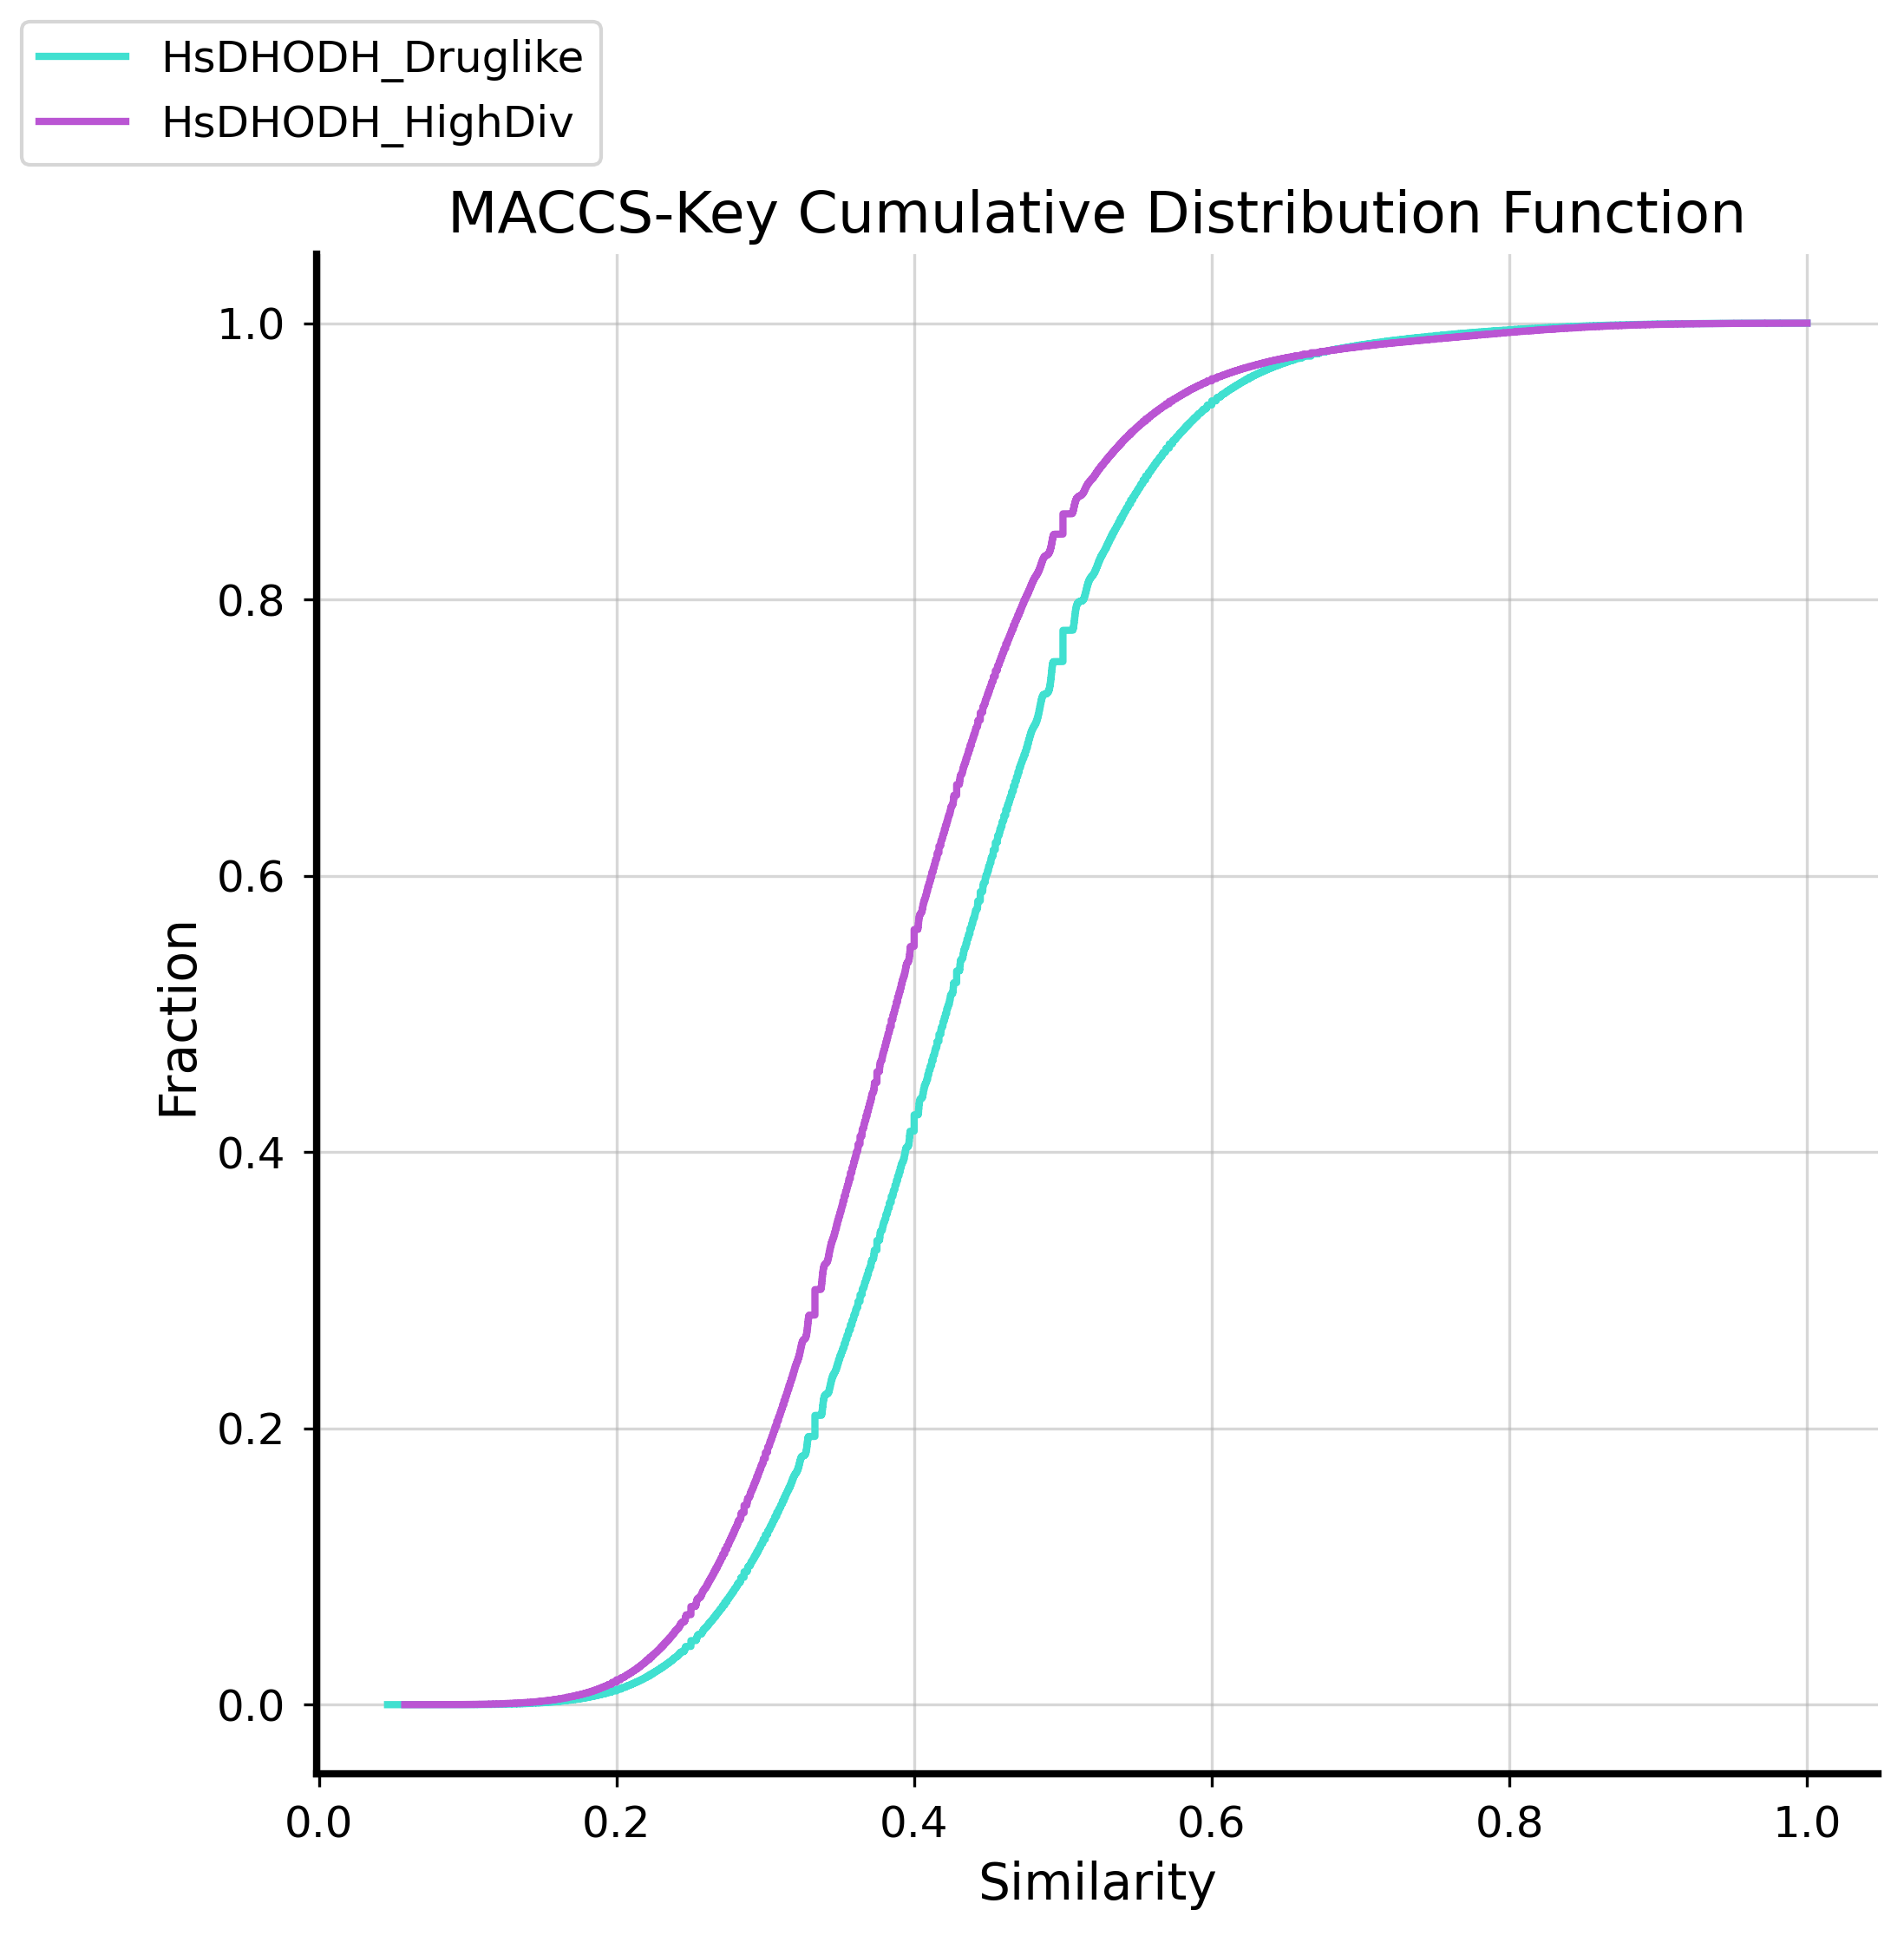

In [5]:
# MACCS fingerprints + CDF
SimMatMACCS_druglike = np.sort(MACCSkeys_fp(smi_druglike))
SimMatMACCS_highdiv = np.sort(MACCSkeys_fp(smi_highdiv))

proportionMACCS_druglike = np.arange(len(SimMatMACCS_druglike)) / (len(SimMatMACCS_druglike) - 1) if len(SimMatMACCS_druglike) > 1 else np.array([])
proportionMACCS_highdiv = np.arange(len(SimMatMACCS_highdiv)) / (len(SimMatMACCS_highdiv) - 1) if len(SimMatMACCS_highdiv) > 1 else np.array([])

fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_subplot(1, 1, 1)
ax.plot(SimMatMACCS_druglike, proportionMACCS_druglike, label="HsDHODH_Druglike", c="turquoise", linewidth=2)
ax.plot(SimMatMACCS_highdiv, proportionMACCS_highdiv, label="HsDHODH_HighDiv", c="mediumorchid", linewidth=2)
ax.grid(alpha=0.5)
ax.set_xlabel("Similarity", fontsize=14)
ax.set_ylabel("Fraction", fontsize=14)
ax.set_title("MACCS-Key Cumulative Distribution Function", fontsize=16)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2.0)
ax.spines["bottom"].set_linewidth(2.0)
ax.tick_params(axis="both", which="major", pad=5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
fig.legend(loc="upper left", fontsize=12, frameon=True)
fig.subplots_adjust(left=0.15, bottom=0.15)
plt.savefig(RESULTS_DIR / "MACCS_CDF.png", dpi=600, bbox_inches="tight")
plt.show()

In [6]:
# MACCS statistics
MACCS_druglike_df = pd.DataFrame(SimMatMACCS_druglike, columns=["MACCS_HsDHODH_Druglike"])
MACCS_highdiv_df = pd.DataFrame(SimMatMACCS_highdiv, columns=["MACCS_HsDHODH_HighDiv"])
MACCS_stats = pd.concat([
    MACCS_druglike_df.describe().round(3),
    MACCS_highdiv_df.describe().round(3)
], axis=1)
MACCS_stats.to_csv(RESULTS_DIR / "MACCS_Statistics.csv")
MACCS_stats

,MACCS_HsDHODH_Druglike,MACCS_HsDHODH_HighDiv
count,1430586.000,1756875.000
mean,0.426,0.396
std,0.111,0.110
min,0.046,0.058
25%,0.350,0.322
50%,0.421,0.386
75%,0.493,0.456
max,1.000,1.000


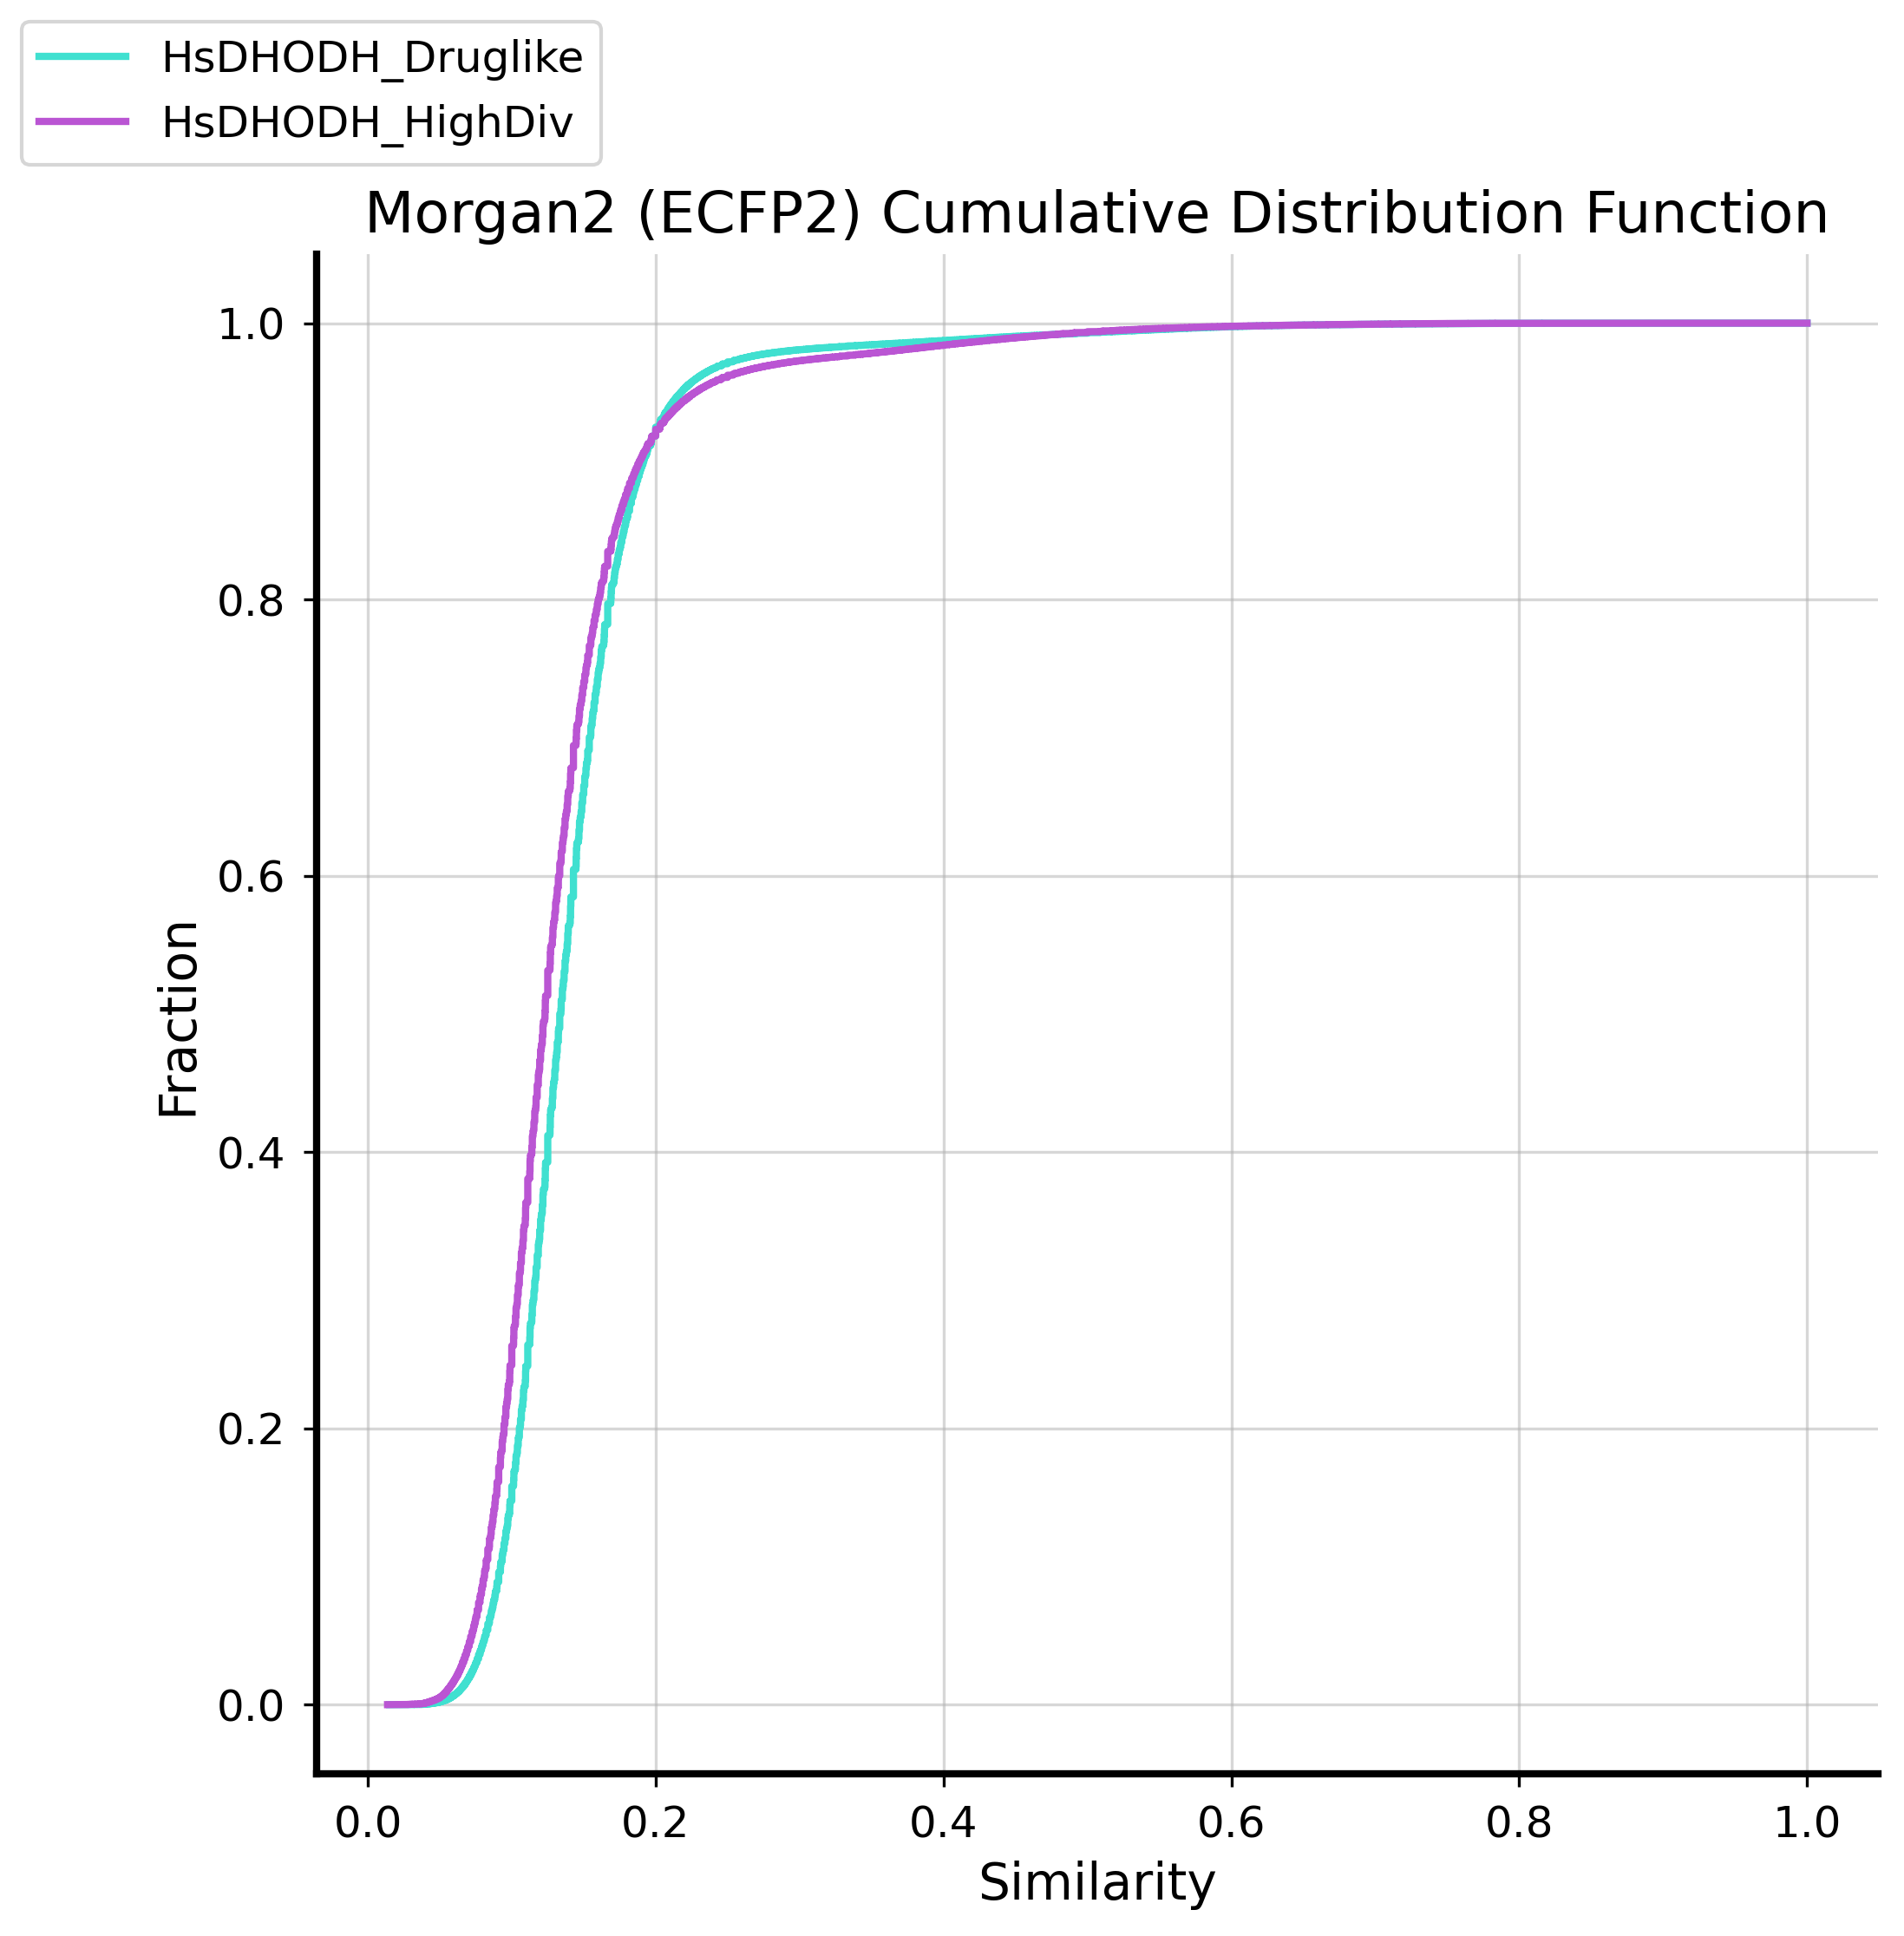

In [7]:
# Morgan2 fingerprints + CDF
SimMatMorgan2_druglike = np.sort(ECFP(smi_druglike, 2))
SimMatMorgan2_highdiv = np.sort(ECFP(smi_highdiv, 2))

proportionMorgan2_druglike = np.arange(len(SimMatMorgan2_druglike)) / (len(SimMatMorgan2_druglike) - 1) if len(SimMatMorgan2_druglike) > 1 else np.array([])
proportionMorgan2_highdiv = np.arange(len(SimMatMorgan2_highdiv)) / (len(SimMatMorgan2_highdiv) - 1) if len(SimMatMorgan2_highdiv) > 1 else np.array([])

fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_subplot(1, 1, 1)
ax.plot(SimMatMorgan2_druglike, proportionMorgan2_druglike, label="HsDHODH_Druglike", c="turquoise", linewidth=2)
ax.plot(SimMatMorgan2_highdiv, proportionMorgan2_highdiv, label="HsDHODH_HighDiv", c="mediumorchid", linewidth=2)
ax.grid(alpha=0.5)
ax.set_xlabel("Similarity", fontsize=14)
ax.set_ylabel("Fraction", fontsize=14)
ax.set_title("Morgan2 (ECFP2) Cumulative Distribution Function", fontsize=16)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2.0)
ax.spines["bottom"].set_linewidth(2.0)
ax.tick_params(axis="both", which="major", pad=5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
fig.legend(loc="upper left", fontsize=12, frameon=True)
fig.subplots_adjust(left=0.15, bottom=0.15)
plt.savefig(RESULTS_DIR / "Morgan2_CDF.png", dpi=600, bbox_inches="tight")
plt.show()

In [8]:
# Morgan2 statistics
Morgan2_druglike_df = pd.DataFrame(SimMatMorgan2_druglike, columns=["Morgan2_HsDHODH_Druglike"])
Morgan2_highdiv_df = pd.DataFrame(SimMatMorgan2_highdiv, columns=["Morgan2_HsDHODH_HighDiv"])
Morgan2_stats = pd.concat([
    Morgan2_druglike_df.describe().round(3),
    Morgan2_highdiv_df.describe().round(3)
], axis=1)
Morgan2_stats.to_csv(RESULTS_DIR / "Morgan2_Statistics.csv")
Morgan2_stats

,Morgan2_HsDHODH_Druglike,Morgan2_HsDHODH_HighDiv
count,1430586.000,1756875.000
mean,0.143,0.136
std,0.061,0.067
min,0.015,0.014
25%,0.111,0.100
50%,0.133,0.123
75%,0.161,0.152
max,1.000,1.000


In [9]:
# Molecular descriptor functions
def MW(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcExactMolWt(mol)

def HBA(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumHBA(mol)

def HBD(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumHBD(mol)

def LOG_P(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return Descriptors.MolLogP(mol)

def TPSA(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcTPSA(mol)

def RB(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumRotatableBonds(mol)

def NumCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")

def NumOxygens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return [atom.GetSymbol() for atom in mol.GetAtoms()].count("O")

def NumNitrogens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return [atom.GetSymbol() for atom in mol.GetAtoms()].count("N")

def FractionOfCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    carbons = [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")
    heavy_atoms = mol.GetNumHeavyAtoms()
    return (carbons / heavy_atoms) if heavy_atoms > 0 else 0

def FractionOfOxygens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    oxygens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("O")
    heavy_atoms = mol.GetNumHeavyAtoms()
    return (oxygens / heavy_atoms) if heavy_atoms > 0 else 0

def FractionOfNitrogens(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    nitrogens = [atom.GetSymbol() for atom in mol.GetAtoms()].count("N")
    heavy_atoms = mol.GetNumHeavyAtoms()
    return (nitrogens / heavy_atoms) if heavy_atoms > 0 else 0

def CSP3(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcFractionCSP3(mol)

def FractionOfChiralCarbons(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    carbons = [atom.GetSymbol() for atom in mol.GetAtoms()].count("C")
    chiral_atoms = [x[0] for x in Chem.FindMolChiralCenters(mol, force=True, includeUnassigned=True)]
    chiral_carbons = [mol.GetAtomWithIdx(i).GetSymbol() for i in chiral_atoms].count("C")
    return (chiral_carbons / carbons) if carbons > 0 else 0

def NumHeavyAtoms(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return mol.GetNumHeavyAtoms()

def Ring(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumRings(mol)

def AliphaticRing(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAliphaticRings(mol)

def AromaticRing(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAromaticRings(mol)

def Heterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumHeterocycles(mol)

def AliphaticHeterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAliphaticHeterocycles(mol)

def AromaticHeterocycle(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumAromaticHeterocycles(mol)

def SpiroAtom(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumSpiroAtoms(mol)

def BridgeheadAtom(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return np.nan
    return rdMolDescriptors.CalcNumBridgeheadAtoms(mol)

In [10]:
# Calculate molecular descriptors
df_complete["MW"] = df_complete["SMILES"].apply(MW)
df_complete["HBA"] = df_complete["SMILES"].apply(HBA)
df_complete["HBD"] = df_complete["SMILES"].apply(HBD)
df_complete["LogP"] = df_complete["SMILES"].apply(LOG_P)
df_complete["TPSA"] = df_complete["SMILES"].apply(TPSA)
df_complete["RotBonds"] = df_complete["SMILES"].apply(RB)
df_complete["NumCarbons"] = df_complete["SMILES"].apply(NumCarbons)
df_complete["NumOxygens"] = df_complete["SMILES"].apply(NumOxygens)
df_complete["NumNitrogens"] = df_complete["SMILES"].apply(NumNitrogens)
df_complete["FractionCarbons"] = df_complete["SMILES"].apply(FractionOfCarbons)
df_complete["FractionOxygens"] = df_complete["SMILES"].apply(FractionOfOxygens)
df_complete["FractionNitrogens"] = df_complete["SMILES"].apply(FractionOfNitrogens)
df_complete["CSP3"] = df_complete["SMILES"].apply(CSP3)
df_complete["ChiralCarbonFraction"] = df_complete["SMILES"].apply(FractionOfChiralCarbons)
df_complete["HeavyAtoms"] = df_complete["SMILES"].apply(NumHeavyAtoms)
df_complete["NumRings"] = df_complete["SMILES"].apply(Ring)
df_complete["AliphaticRings"] = df_complete["SMILES"].apply(AliphaticRing)
df_complete["AromaticRings"] = df_complete["SMILES"].apply(AromaticRing)
df_complete["Heterocycles"] = df_complete["SMILES"].apply(Heterocycle)
df_complete["AliphaticHeterocycles"] = df_complete["SMILES"].apply(AliphaticHeterocycle)
df_complete["AromaticHeterocycles"] = df_complete["SMILES"].apply(AromaticHeterocycle)
df_complete["SpiroAtoms"] = df_complete["SMILES"].apply(SpiroAtom)
df_complete["BridgeheadAtoms"] = df_complete["SMILES"].apply(BridgeheadAtom)

print("Descriptors calculated")

Descriptors calculated


In [11]:
# Descriptor statistics
descriptor_cols = [
    "MW", "HBA", "HBD", "LogP", "TPSA", "RotBonds",
    "NumCarbons", "NumOxygens", "NumNitrogens",
    "FractionCarbons", "FractionOxygens", "FractionNitrogens",
    "CSP3", "ChiralCarbonFraction", "HeavyAtoms", "NumRings",
    "AliphaticRings", "AromaticRings", "Heterocycles",
    "AliphaticHeterocycles", "AromaticHeterocycles",
    "SpiroAtoms", "BridgeheadAtoms"
 ]

descriptor_stats = df_complete.groupby("Database")[descriptor_cols].agg(["mean", "std", "min", "max"]).round(2)
descriptor_stats.to_csv(RESULTS_DIR / "Descriptor_Statistics.csv")
descriptor_stats.head()

MW                          HBA                 HBD  \
                    mean    std     min     max  mean   std min max  mean   
Database                                                                    
HsDHODH_Druglike  288.04  55.89  167.06  493.01  4.40  1.39   2   9  2.60   
HsDHODH_HighDiv   310.79  59.13  169.04  488.92  4.61  1.28   2   9  2.74   

                        ... AromaticHeterocycles     SpiroAtoms               \
                   std  ...                  min max       mean  std min max   
Database                ...                                                    
HsDHODH_Druglike  0.71  ...                    0   3        0.0  0.0   0   0   
HsDHODH_HighDiv   0.83  ...                    0   3        0.0  0.0   0   0   

                 BridgeheadAtoms               
                            mean  std min max  
Database                                       
HsDHODH_Druglike             0.0  0.0   0   0  
HsDHODH_HighDiv              0.0  0.0   0   0  

[2 rows x 92 columns]

/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/1459369552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

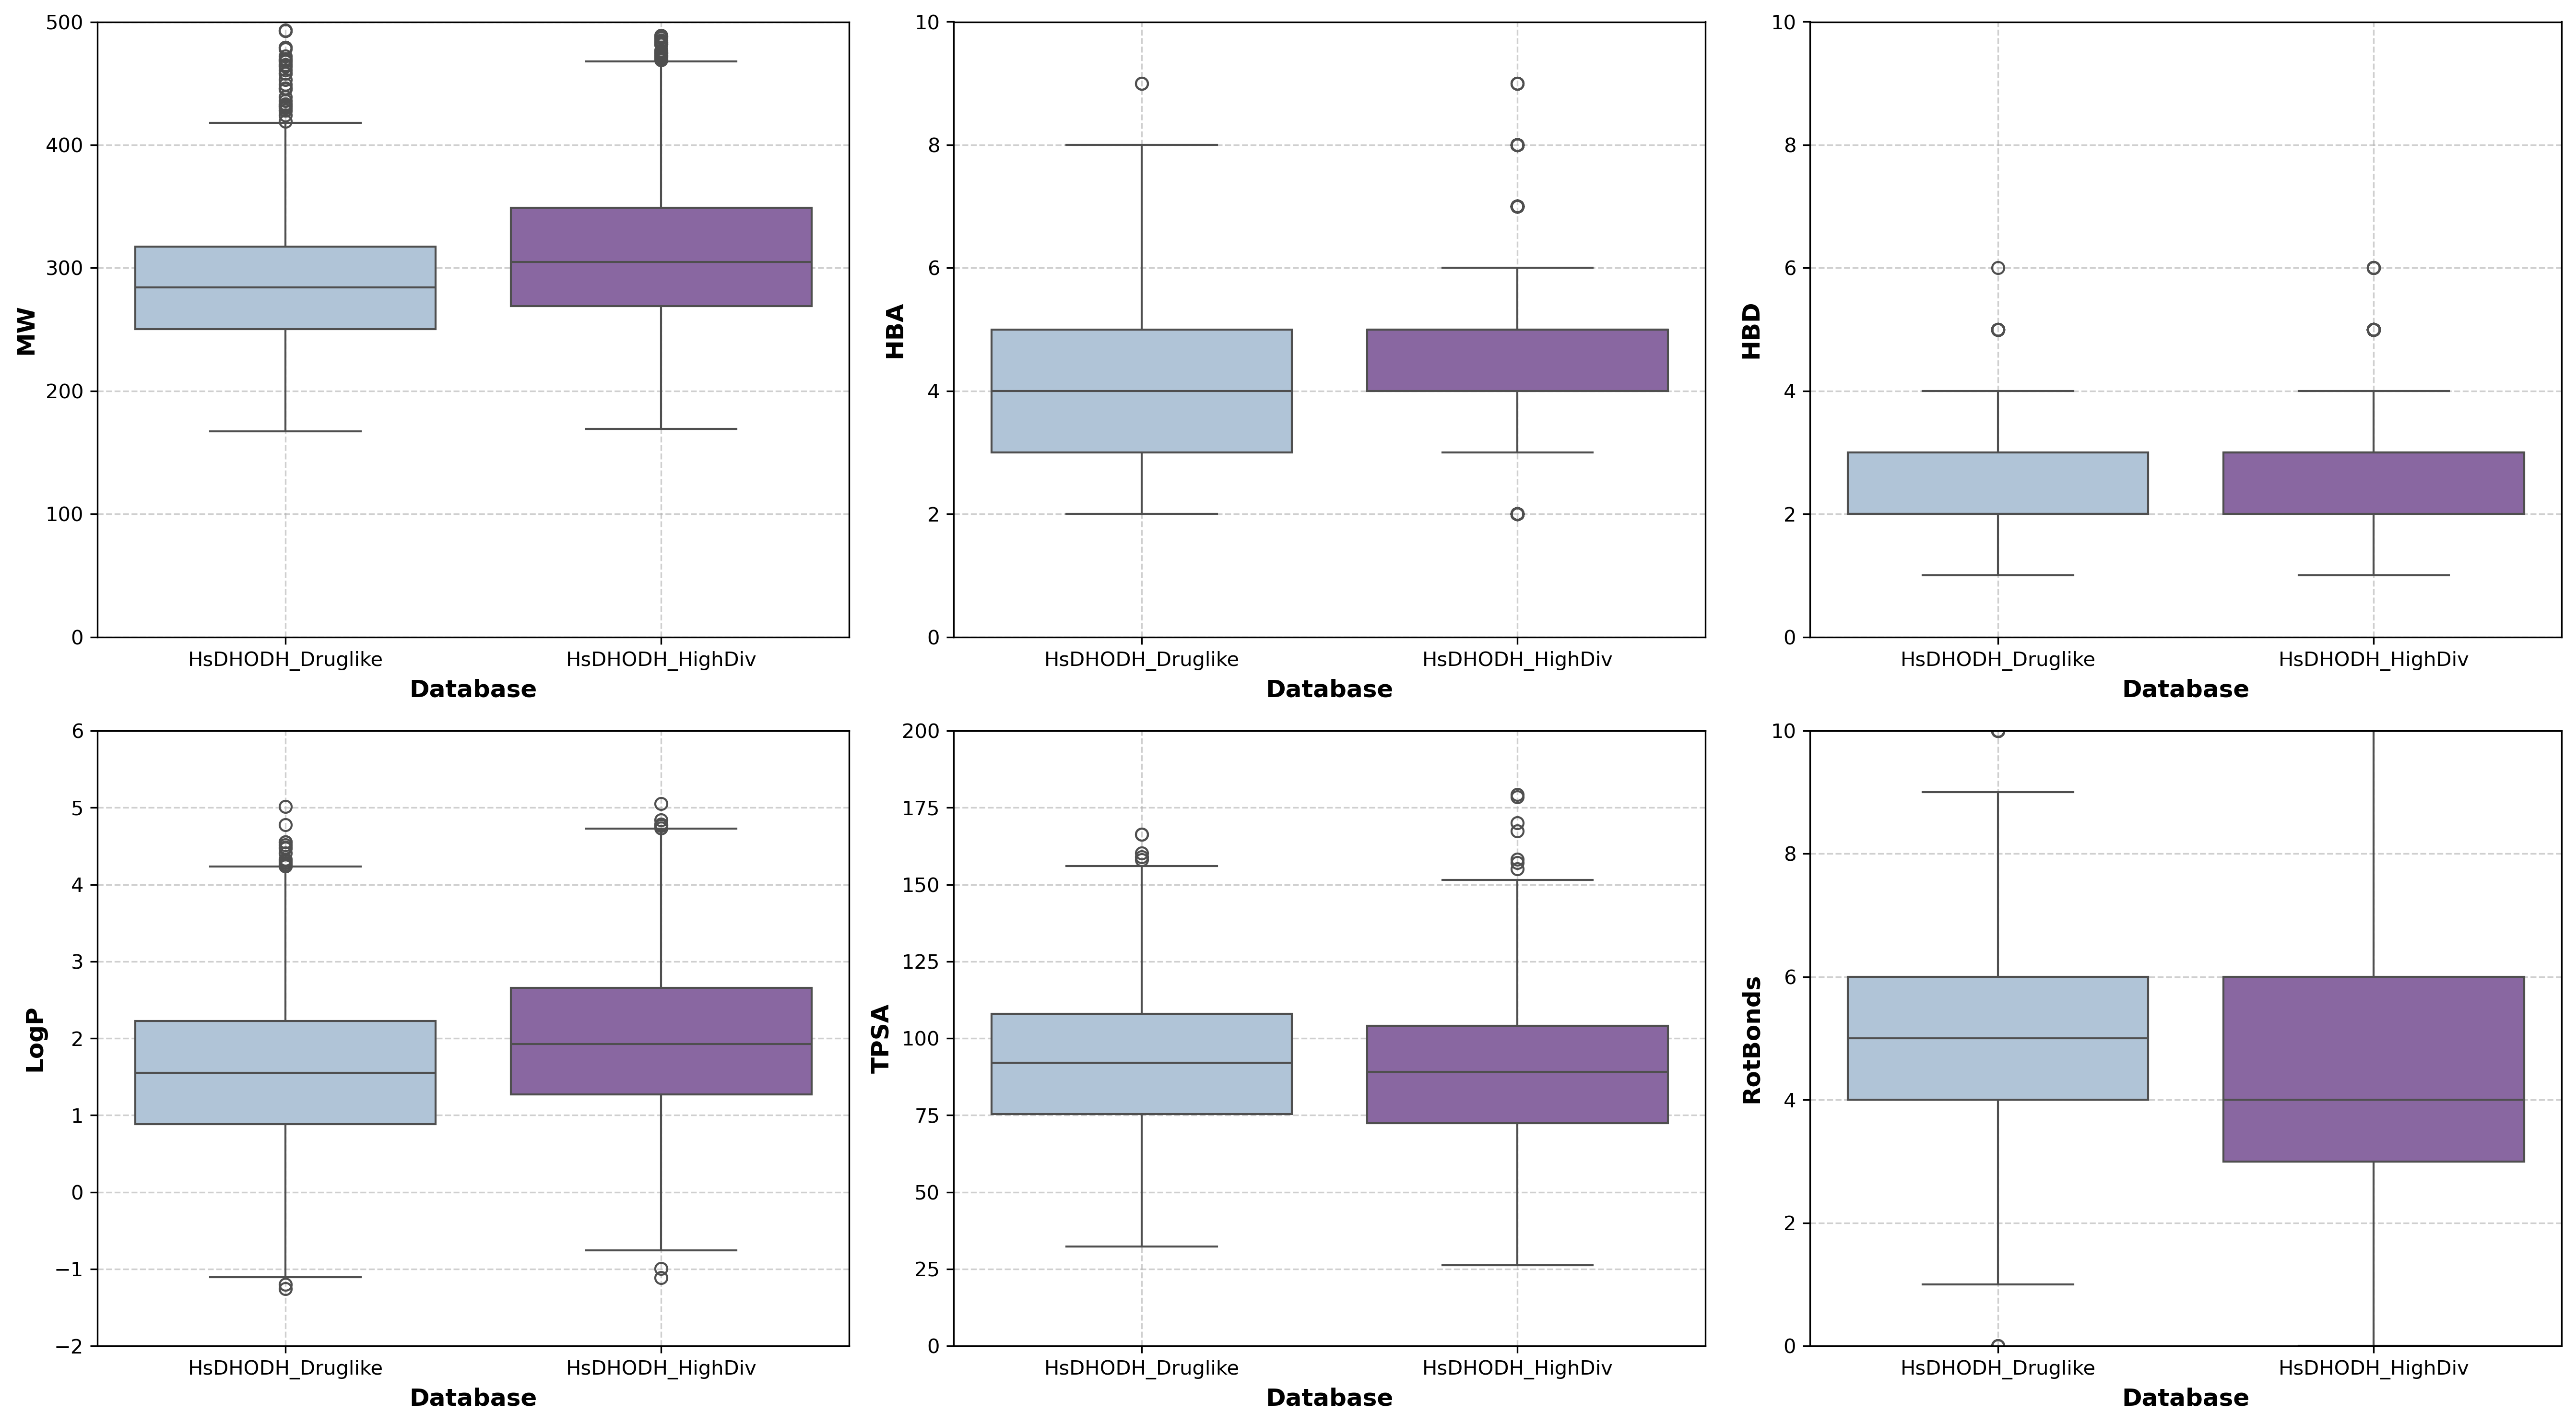

In [12]:
# Boxplots of drug-like properties
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
variables = ["MW", "HBA", "HBD", "LogP", "TPSA", "RotBonds"]
limits = {
    "MW": (0, 500),
    "HBA": (0, 10),
    "HBD": (0, 10),
    "LogP": (-2, 6),
    "TPSA": (0, 200),
    "RotBonds": (0, 10)
}

for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(
        x="Database",
        y=var,
        data=df_complete,
        order=ordre_desired,
        palette="BuPu",
        ax=ax
    )
    ax.set_xlabel("Database", fontsize=12, fontweight="bold")
    ax.set_ylabel(var, fontsize=12, fontweight="bold")
    if var in limits:
        ax.set_ylim(limits[var])
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Boxplots_Descriptors.png", dpi=600, bbox_inches="tight")
plt.show()

/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/3897133582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/3897133582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/3897133582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zw/yr2q39g93yj7zprvshxyj6840000gn/T/ipykernel_70503/3897133582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is dep

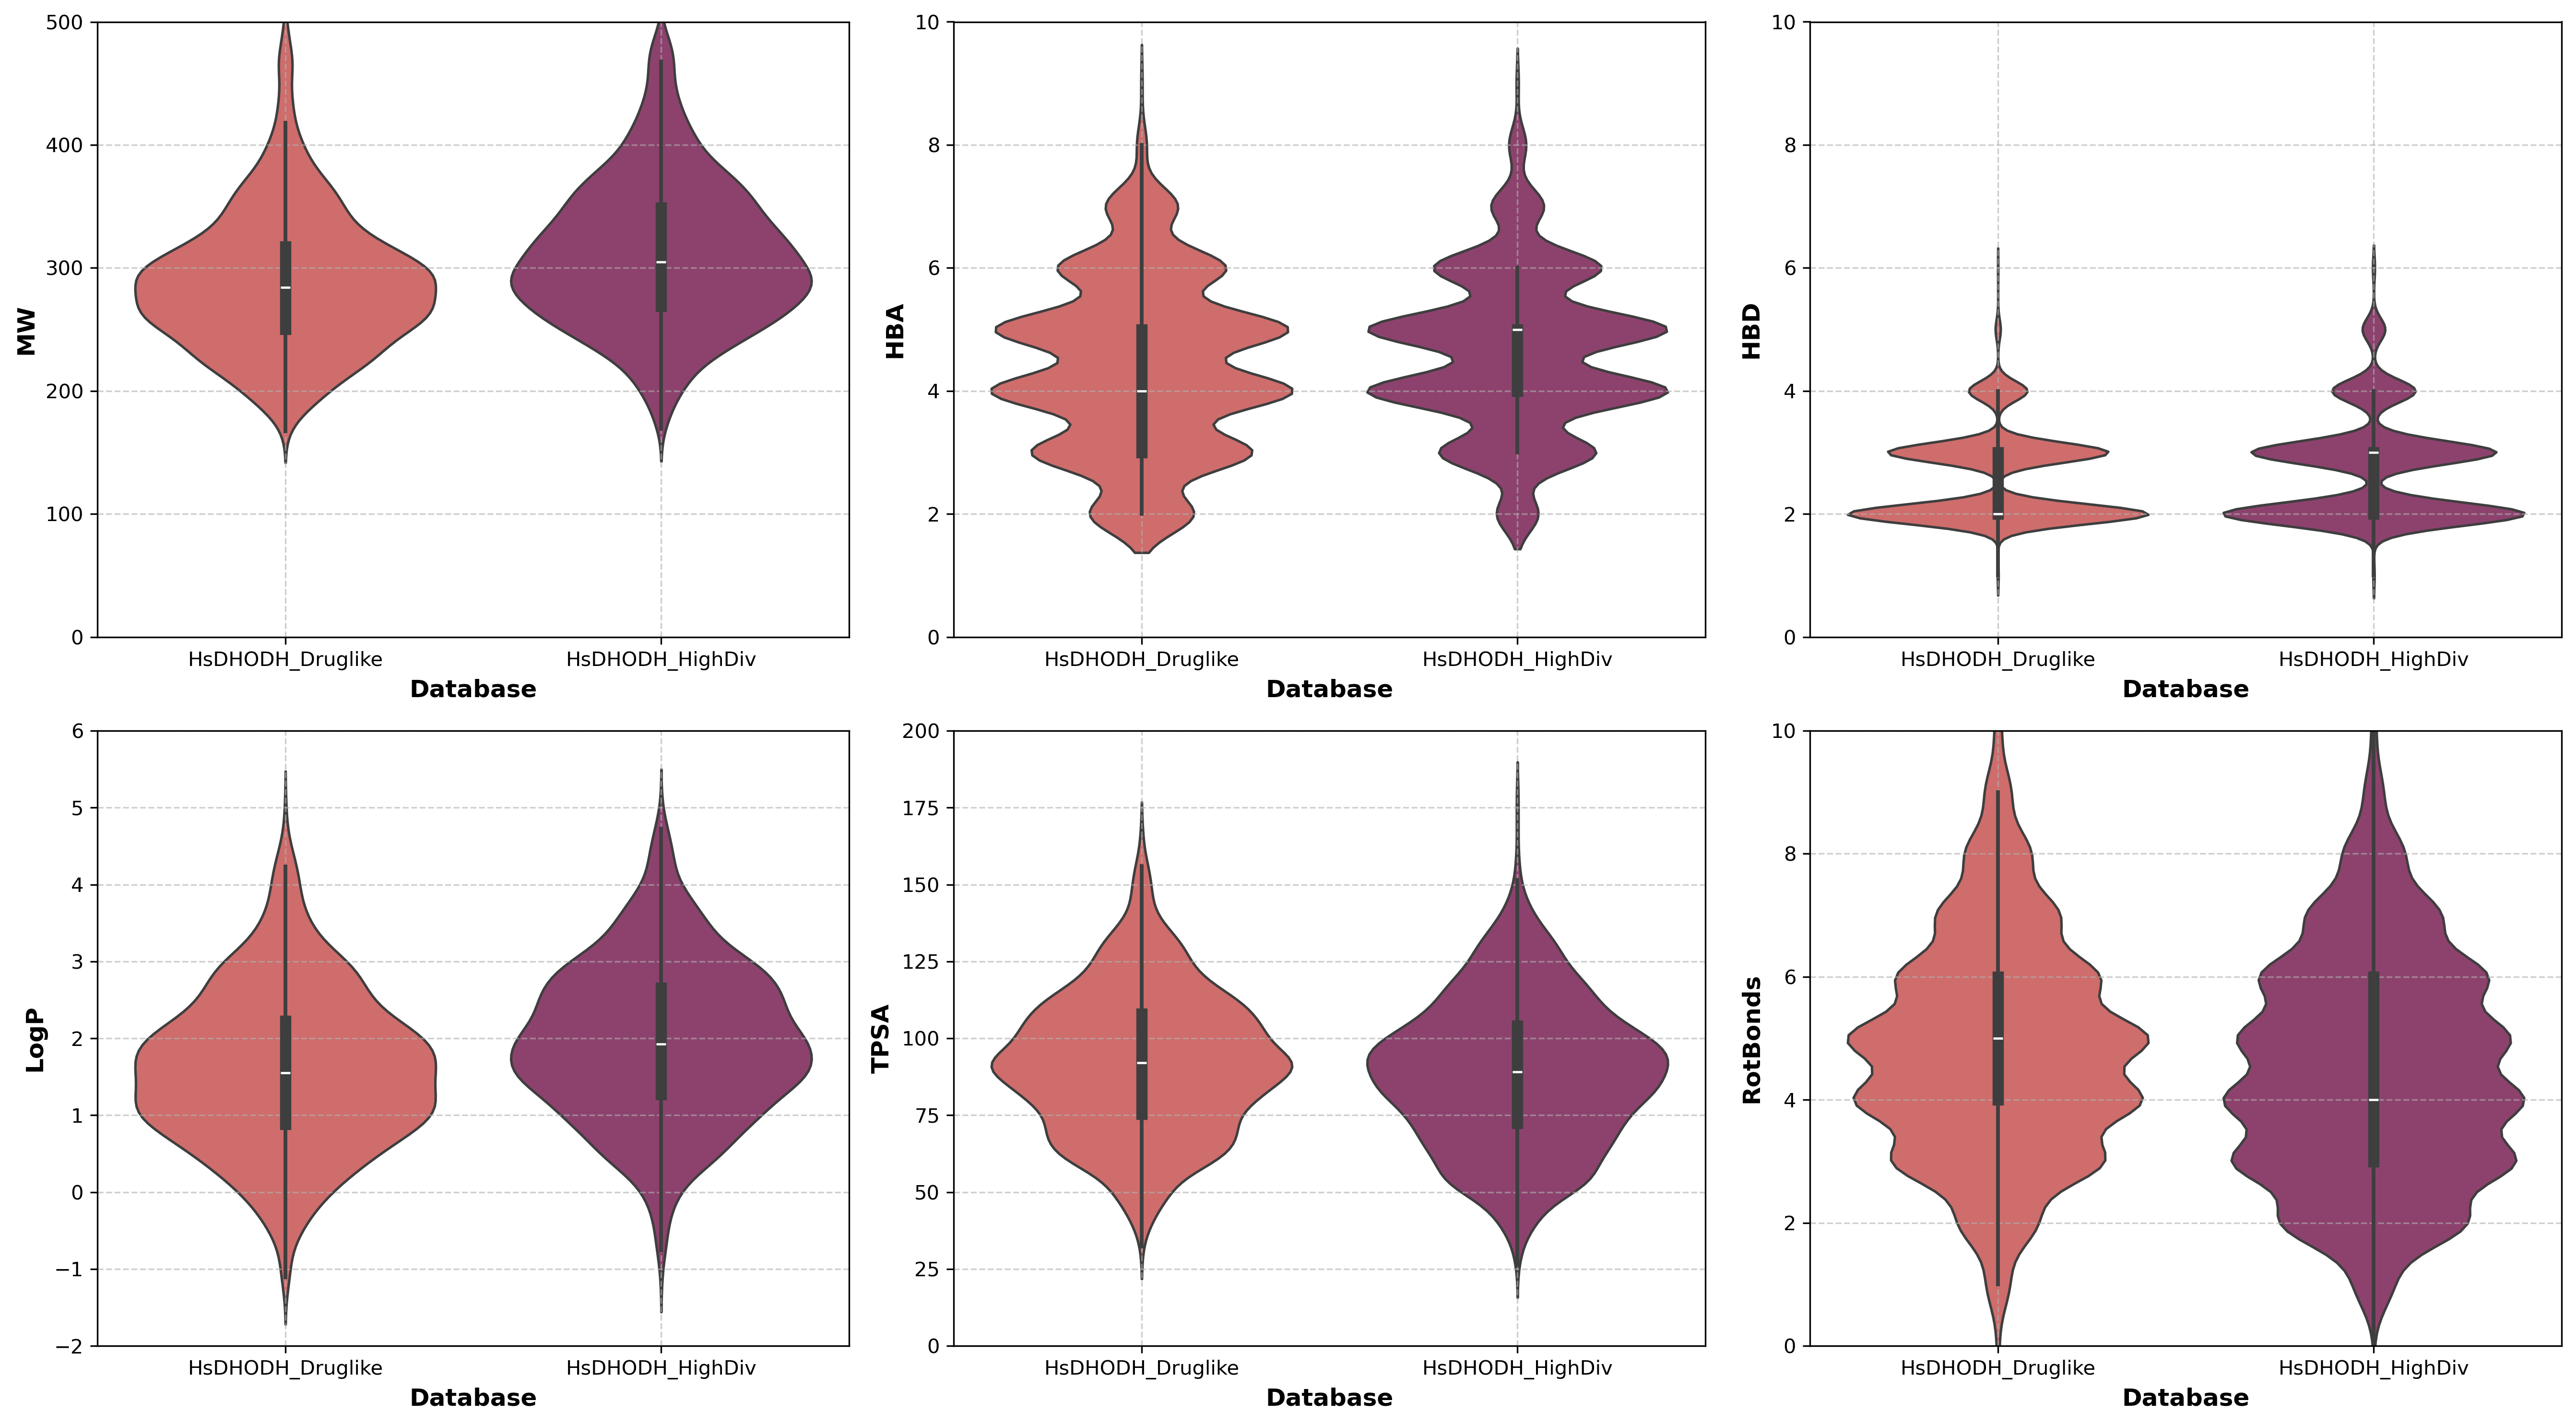

In [13]:
# Violinplots of drug-like properties
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
variables = ["MW", "HBA", "HBD", "LogP", "TPSA", "RotBonds"]
limits = {
    "MW": (0, 500),
    "HBA": (0, 10),
    "HBD": (0, 10),
    "LogP": (-2, 6),
    "TPSA": (0, 200),
    "RotBonds": (0, 10)
}

for ax, var in zip(axes.flatten(), variables):
    sns.violinplot(
        x="Database",
        y=var,
        data=df_complete,
        order=ordre_desired,
        palette="flare",
        ax=ax
    )
    ax.set_xlabel("Database", fontsize=12, fontweight="bold")
    ax.set_ylabel(var, fontsize=12, fontweight="bold")
    if var in limits:
        ax.set_ylim(limits[var])
    ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Violinplots_Descriptors.png", dpi=600, bbox_inches="tight")
plt.show()

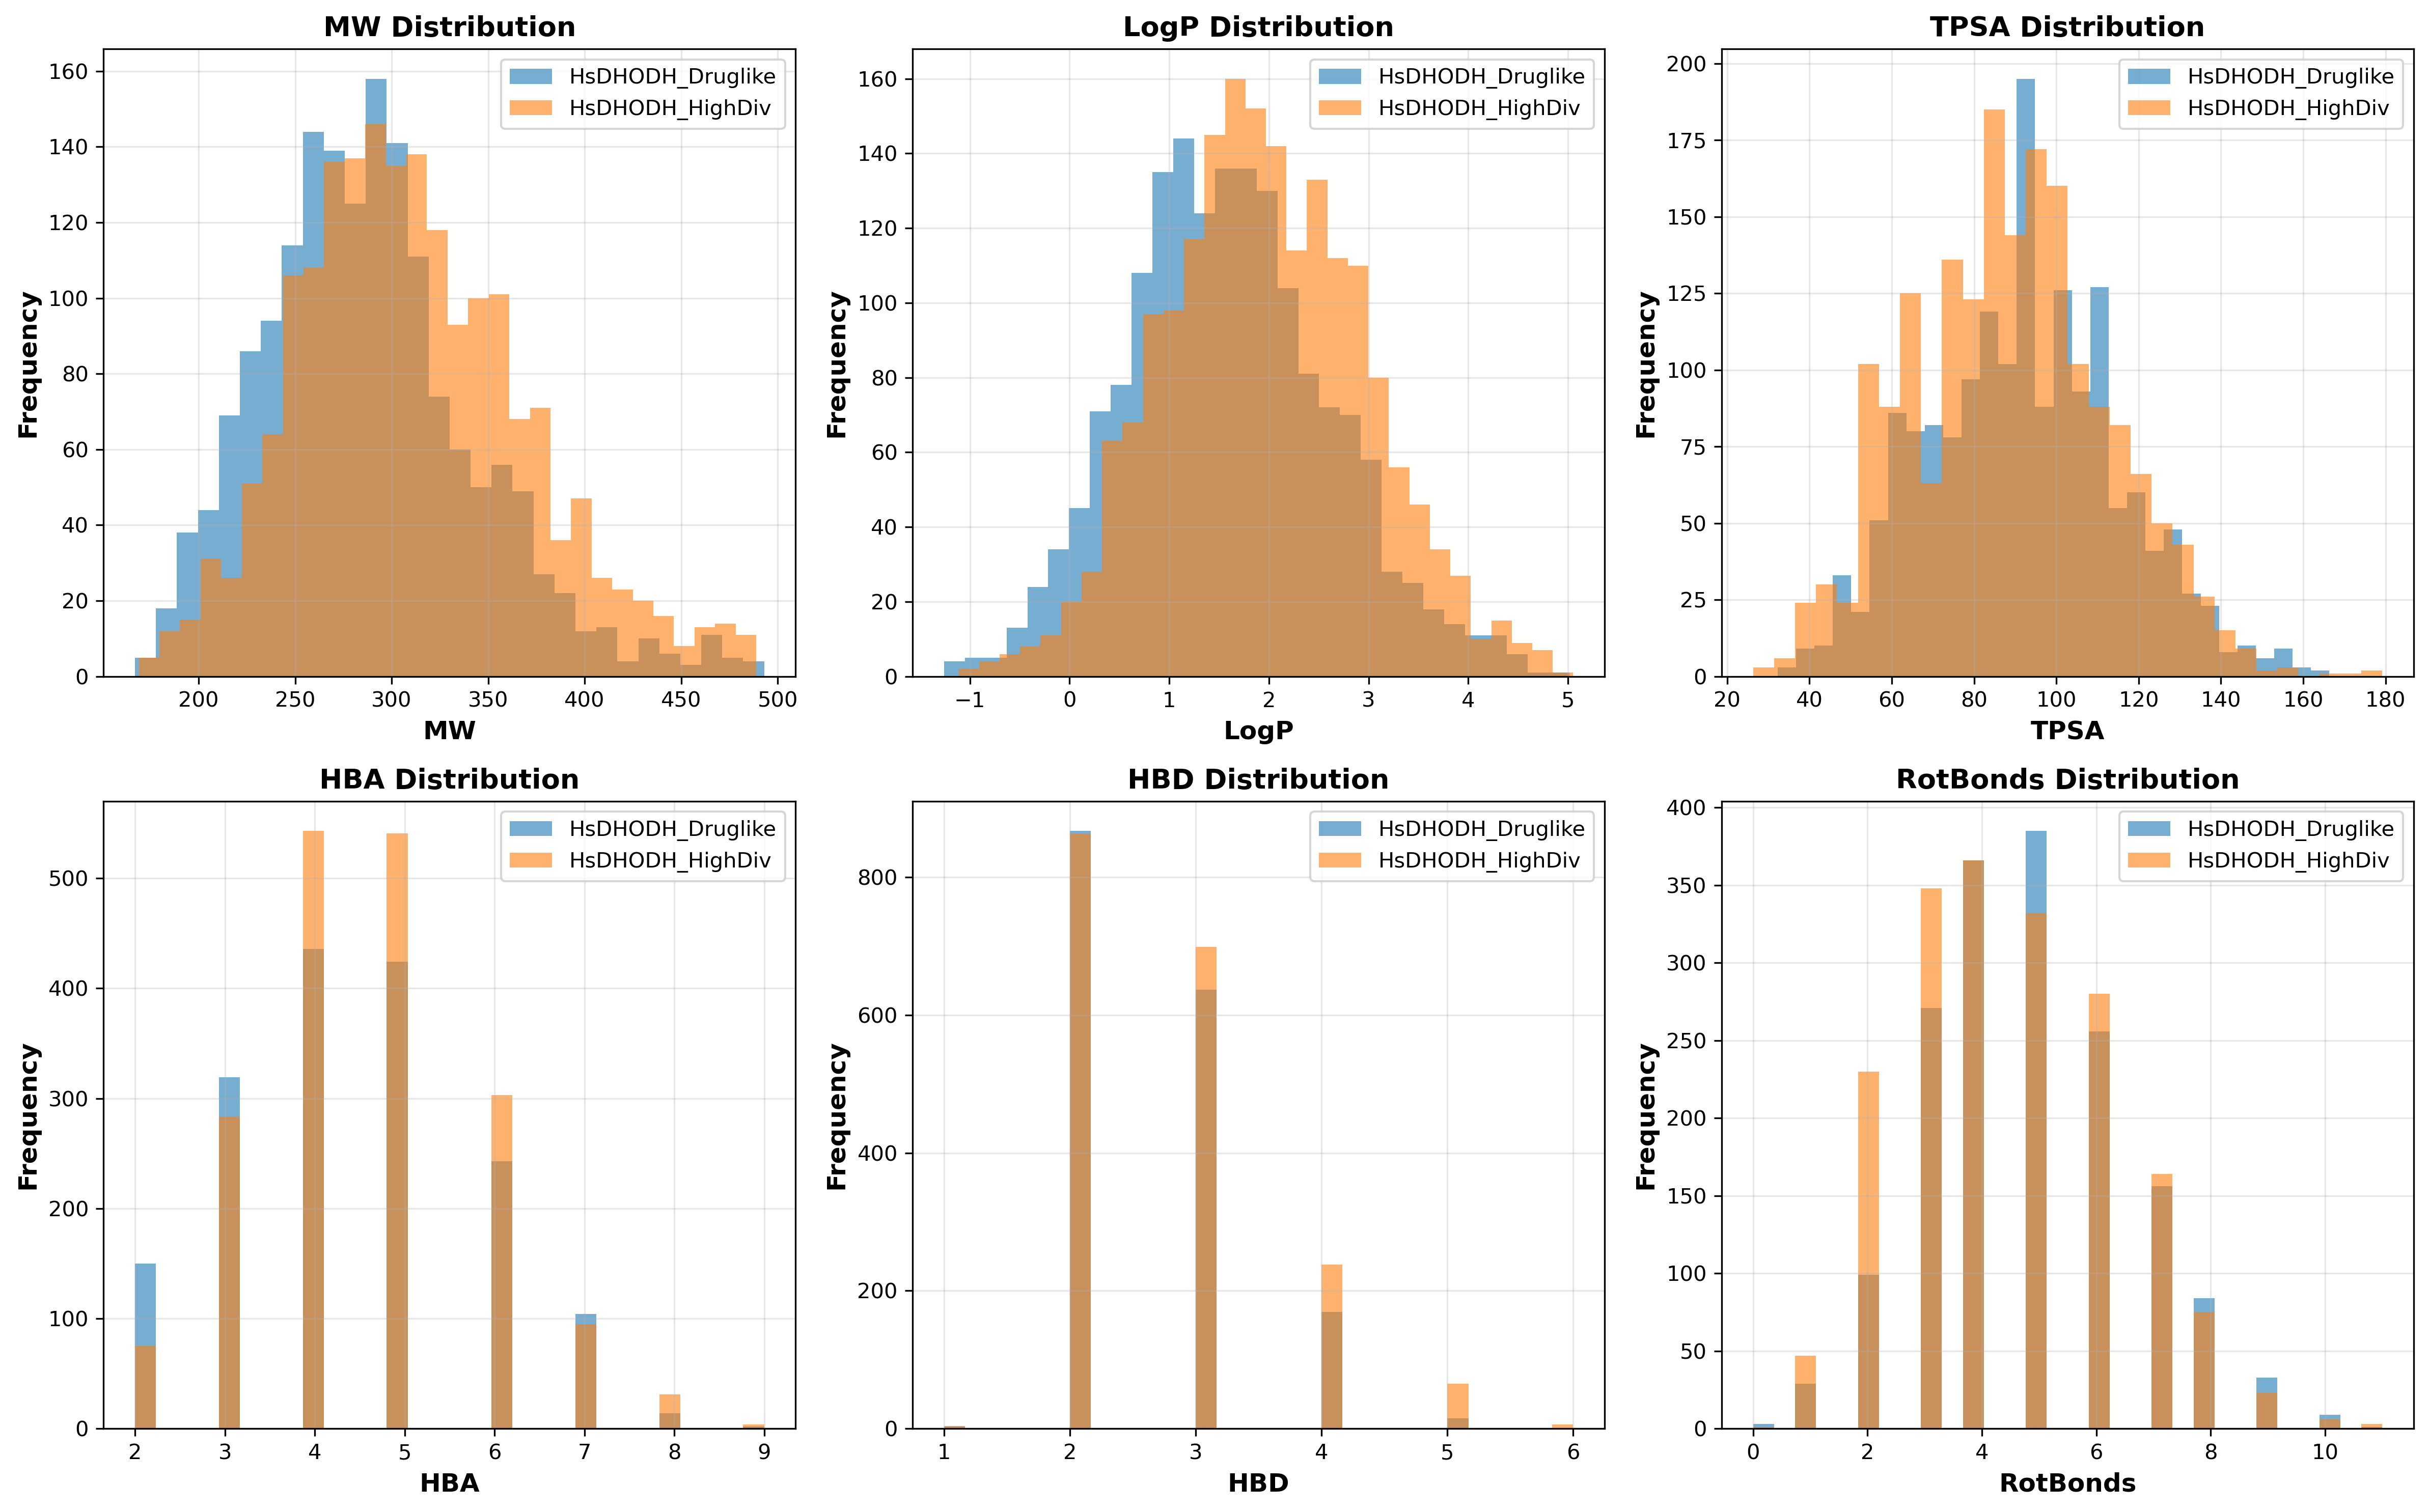

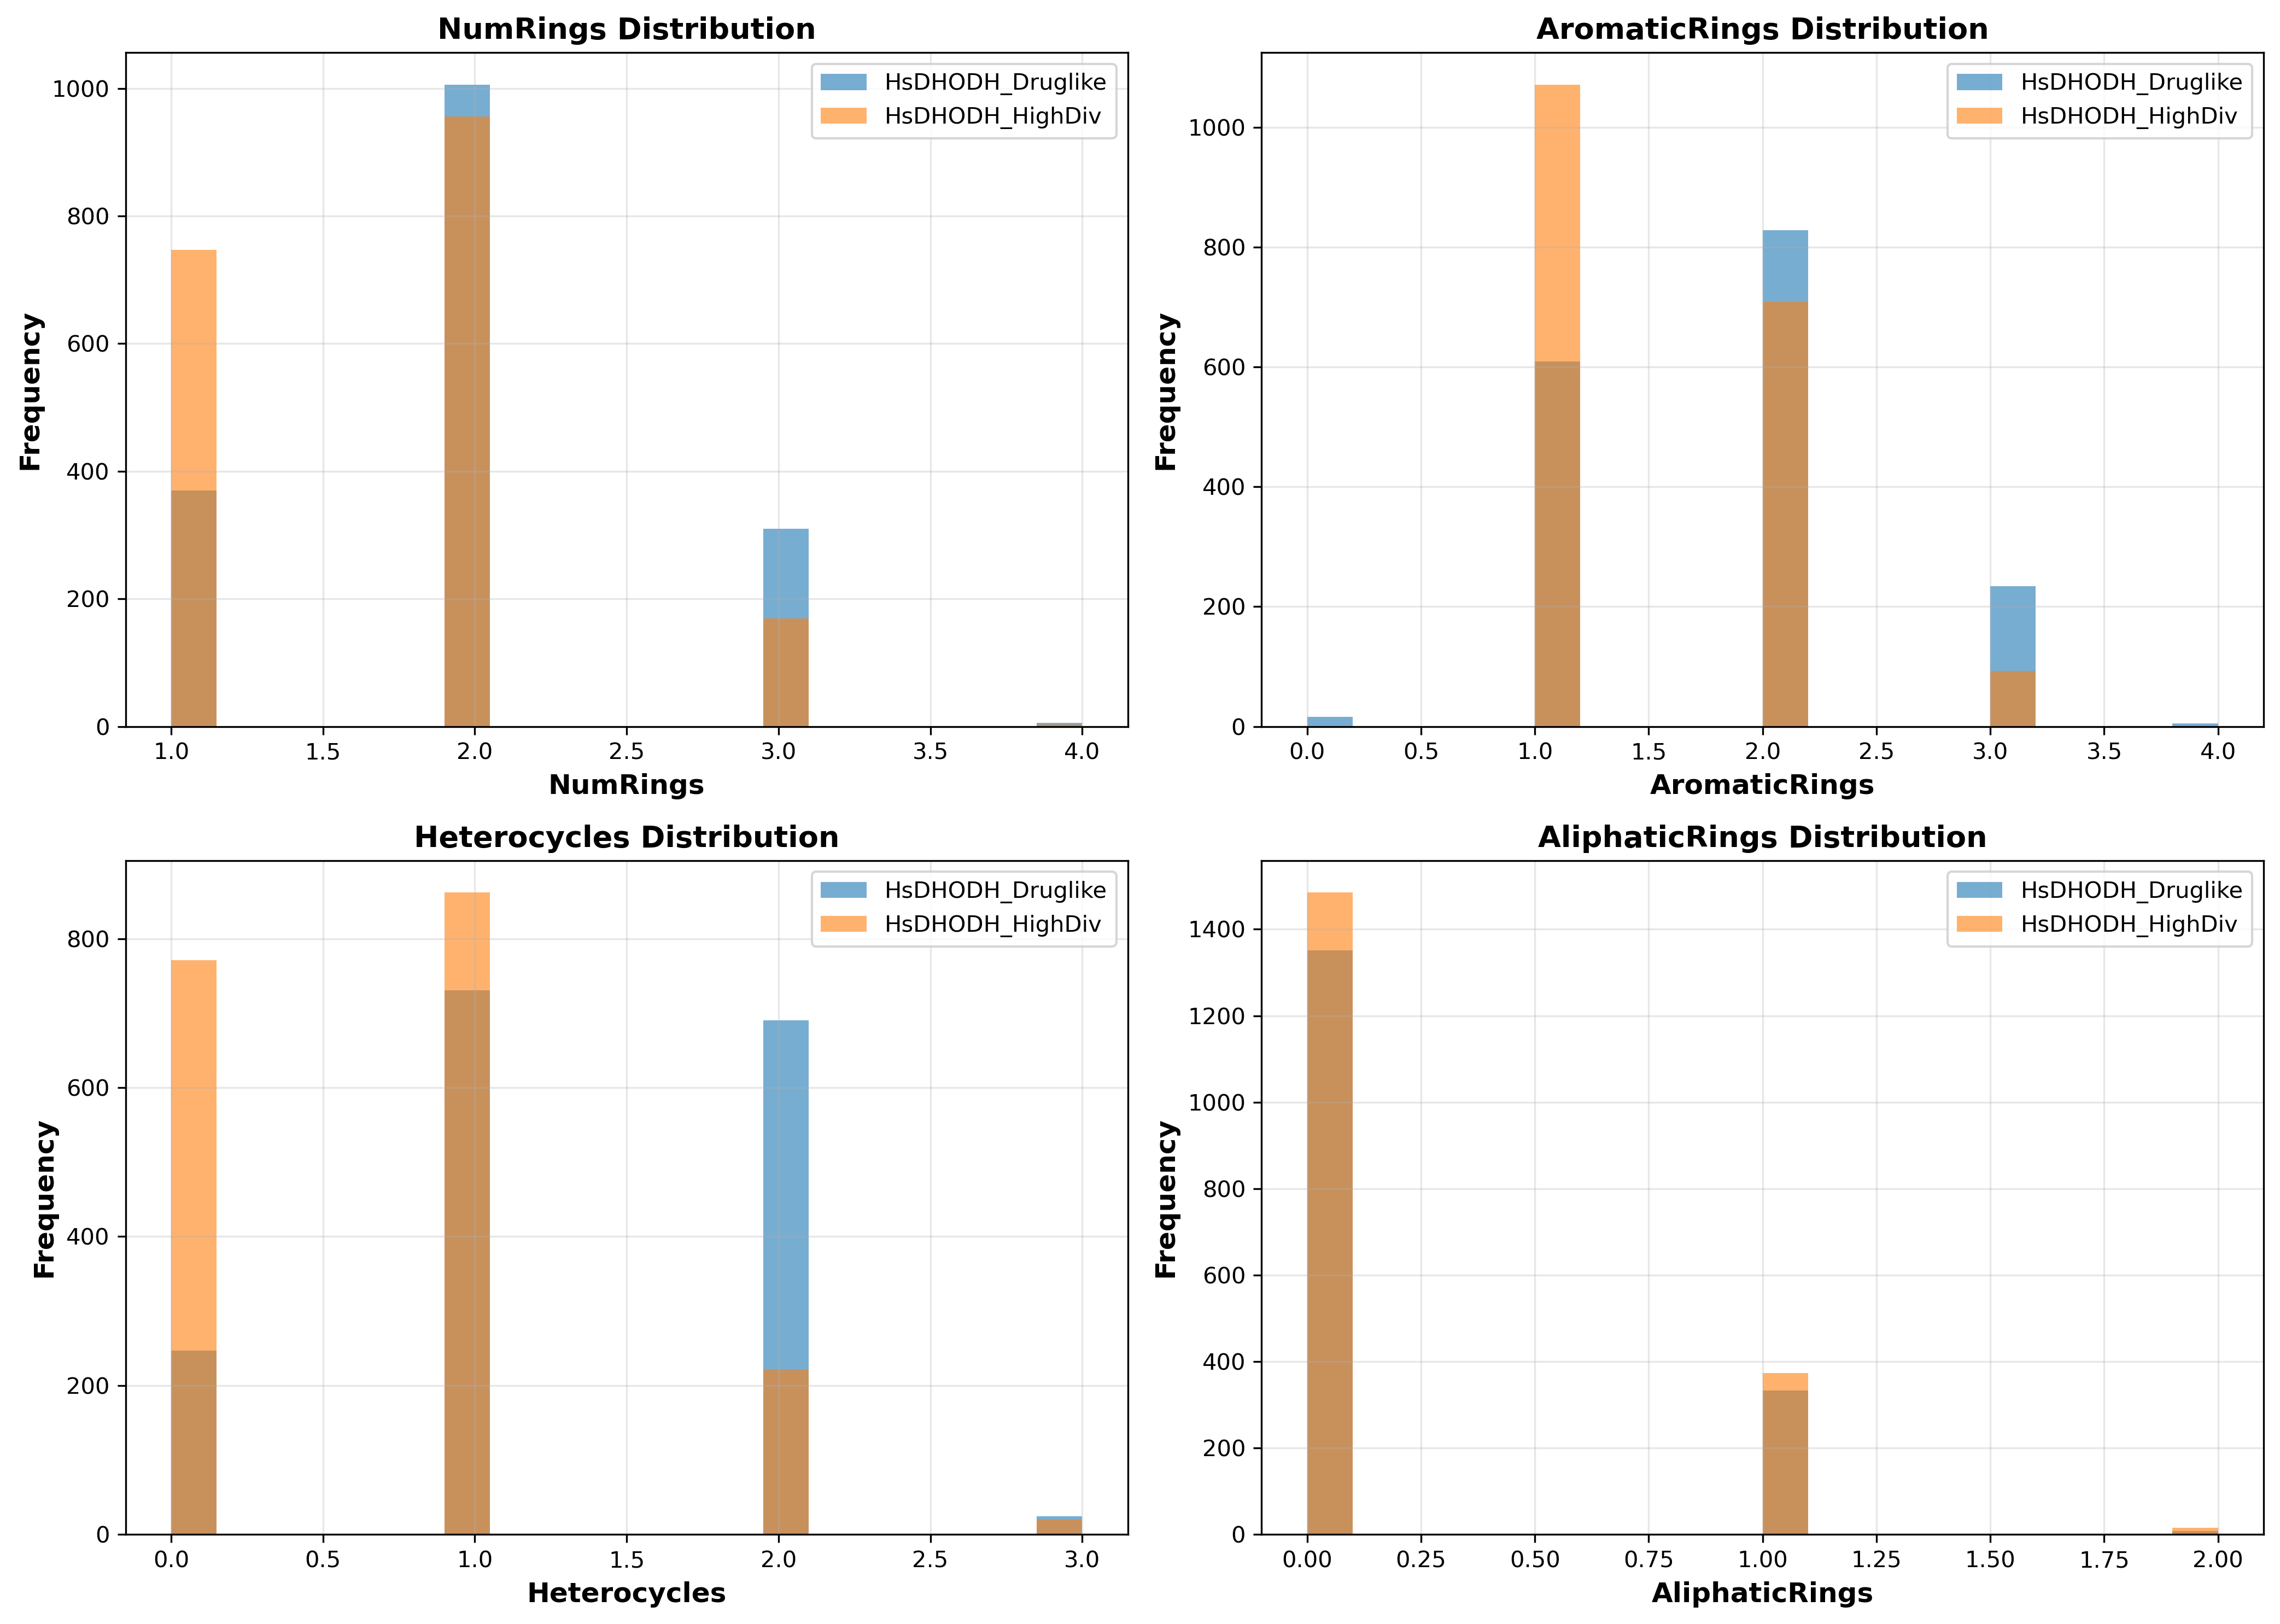

In [14]:
# Distribution of key molecular properties
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)
properties = ["MW", "LogP", "TPSA", "HBA", "HBD", "RotBonds"]

for ax, prop in zip(axes.flatten(), properties):
    for db in ordre_desired:
        data = df_complete[df_complete["Database"] == db][prop].dropna()
        ax.hist(data, bins=30, alpha=0.6, label=db)
    ax.set_xlabel(prop, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=12, fontweight="bold")
    ax.set_title(f"{prop} Distribution", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Distributions_MolecularProperties.png", dpi=600, bbox_inches="tight")
plt.show()

# Distribution of ring systems
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
ring_properties = ["NumRings", "AromaticRings", "Heterocycles", "AliphaticRings"]

for ax, prop in zip(axes.flatten(), ring_properties):
    for db in ordre_desired:
        data = df_complete[df_complete["Database"] == db][prop].dropna()
        ax.hist(data, bins=20, alpha=0.6, label=db)
    ax.set_xlabel(prop, fontsize=12, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=12, fontweight="bold")
    ax.set_title(f"{prop} Distribution", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "Distributions_RingSystems.png", dpi=600, bbox_inches="tight")
plt.show()

## 3. Additional Physicochemical Plots

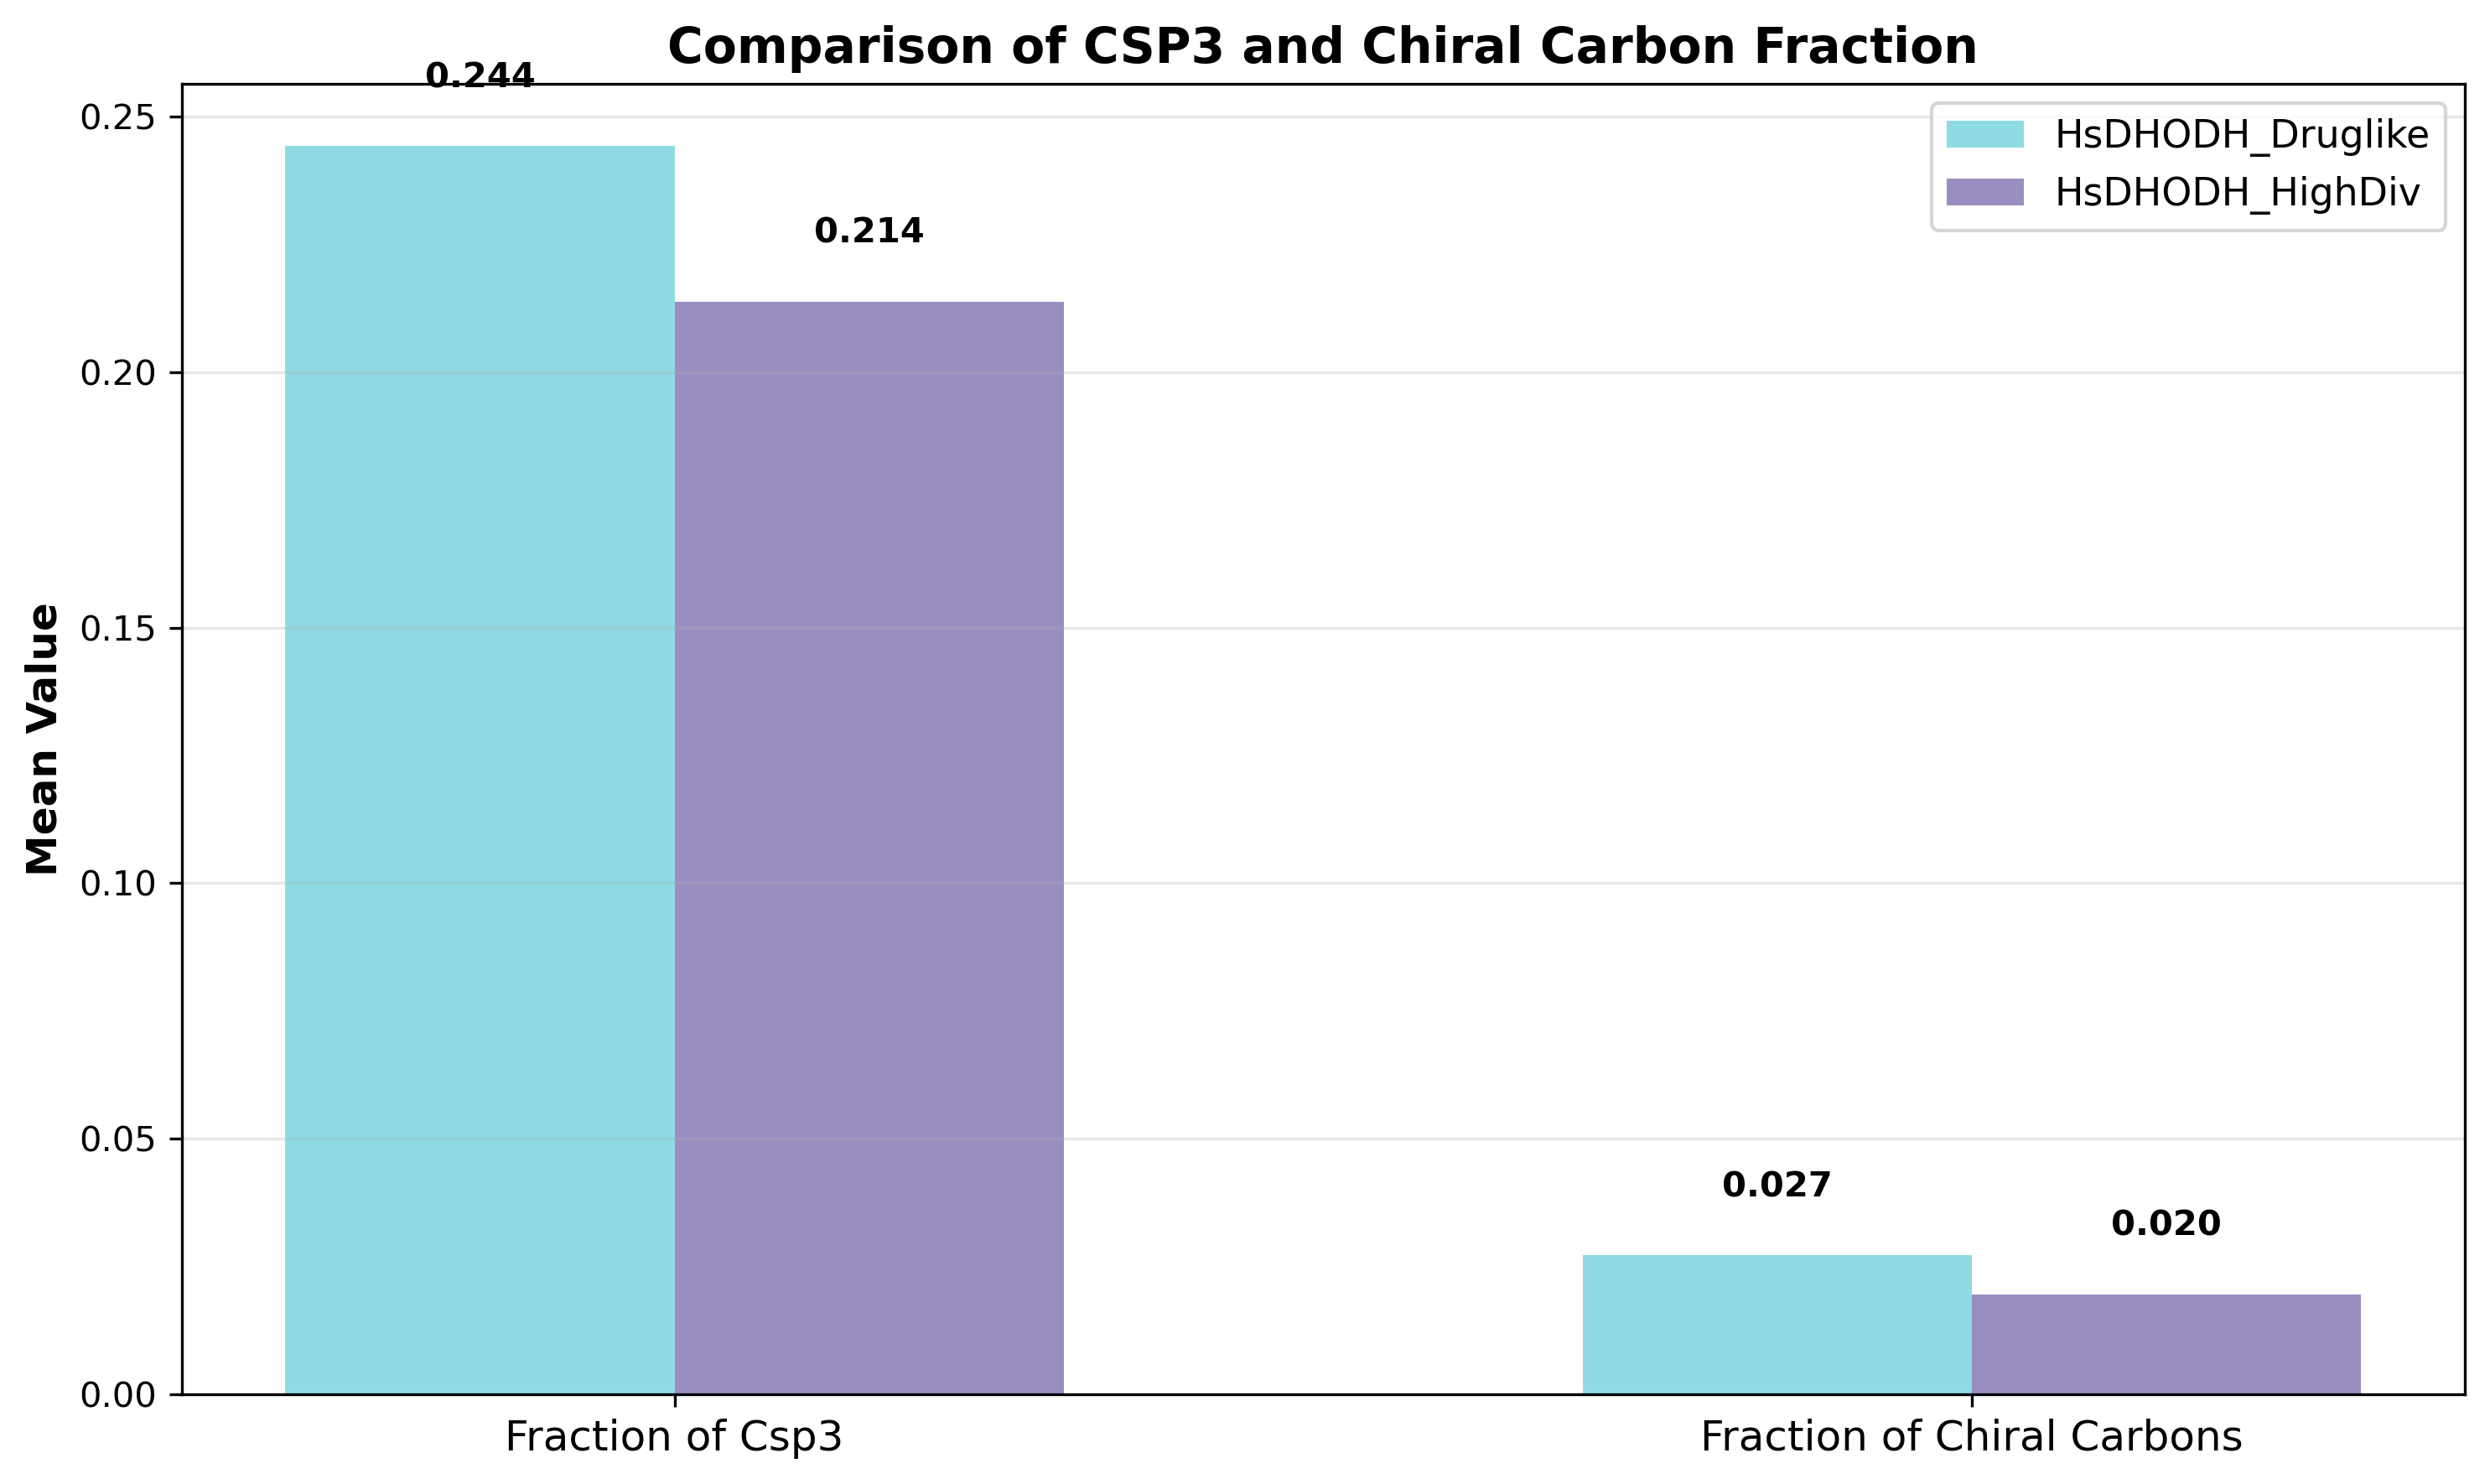

In [15]:
# Comparison of CSP3 and chiral carbon fraction
fig = plt.figure(figsize=(10, 6), dpi=300)
descriptor_means = df_complete.groupby("Database")[["CSP3", "ChiralCarbonFraction"]].mean()

selected_properties = ["CSP3", "ChiralCarbonFraction"]
property_names = ["Fraction of Csp3", "Fraction of Chiral Carbons"]
colors = ["#73d2dd", "#8172B2"]

databases = descriptor_means.index.tolist()
pos_x = np.arange(len(selected_properties))
width = 0.3

for i, db in enumerate(databases):
    values = [descriptor_means.loc[db, prop] for prop in selected_properties]
    bars = plt.bar(pos_x + i * width, values, width, label=db, color=colors[i], alpha=0.8)
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.xticks(pos_x + width / 2, property_names, fontsize=12)
plt.ylabel("Mean Value", fontsize=12, fontweight="bold")
plt.title("Comparison of CSP3 and Chiral Carbon Fraction", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "CSP3_ChiralCarbon_Comparison.png", dpi=600, bbox_inches="tight")
plt.show()

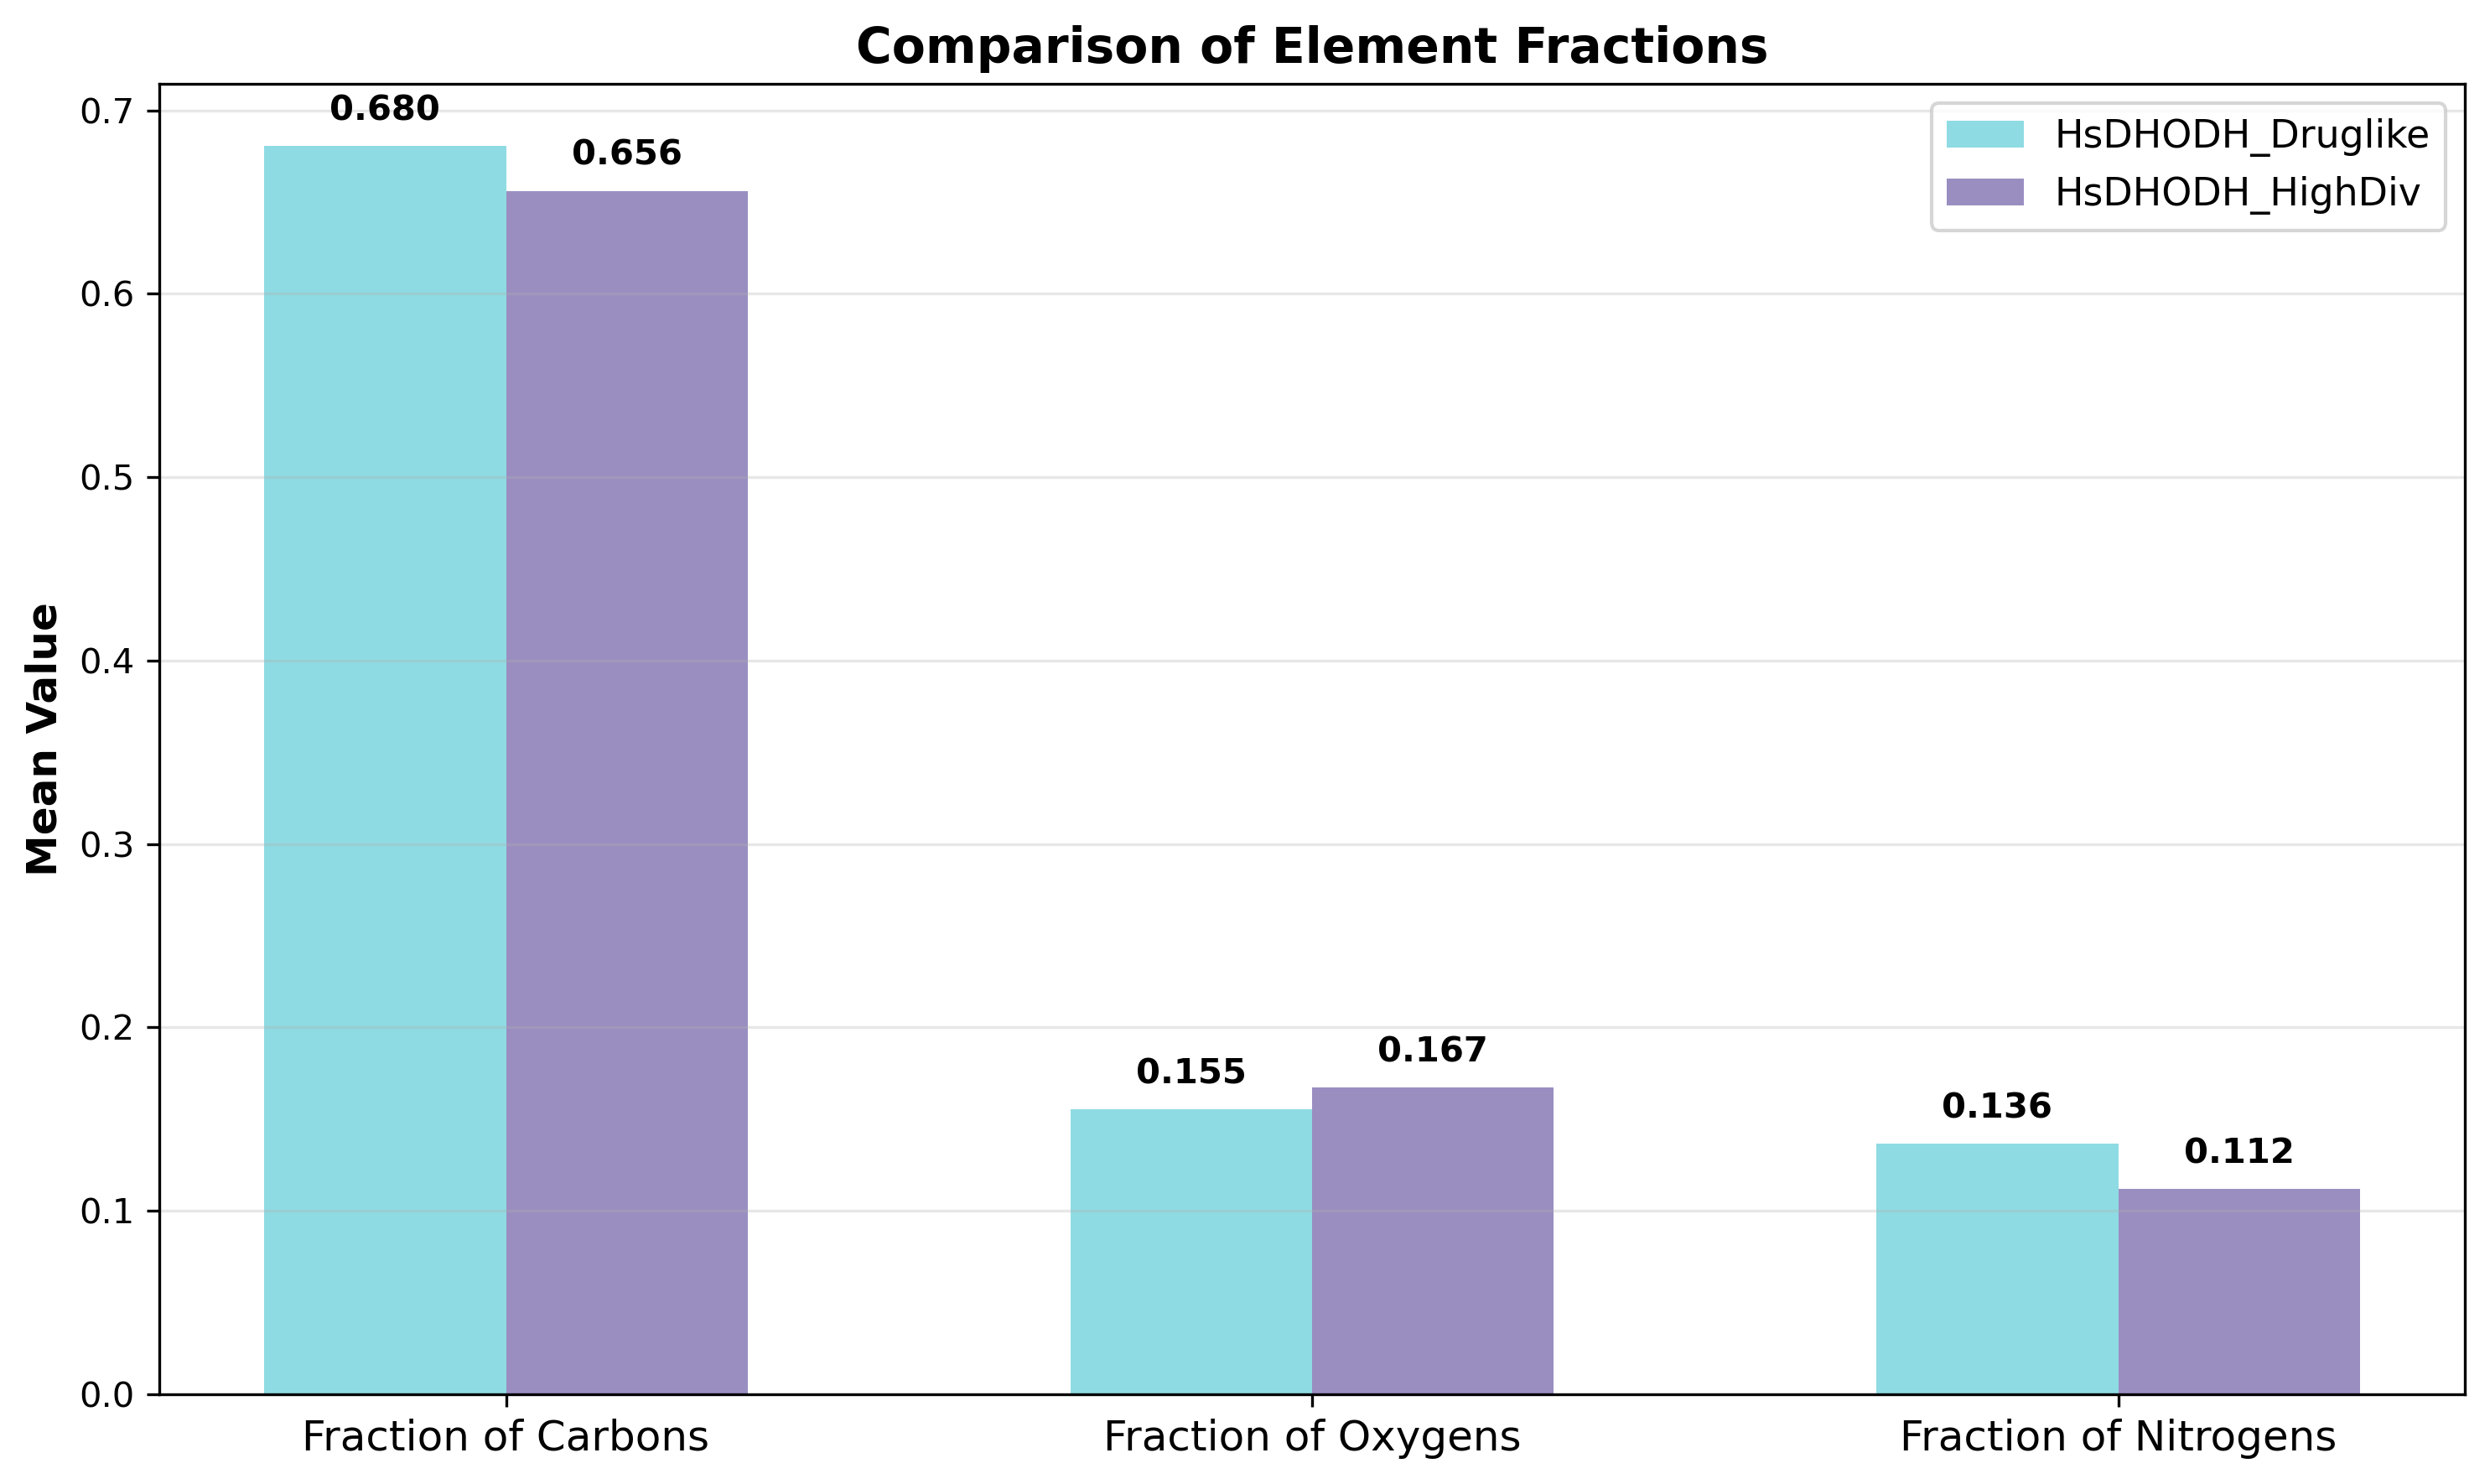

In [16]:
# Comparison of element fractions
fig = plt.figure(figsize=(10, 6), dpi=300)
descriptor_means = df_complete.groupby("Database")[["FractionCarbons", "FractionOxygens", "FractionNitrogens"]].mean()

selected_properties = ["FractionCarbons", "FractionOxygens", "FractionNitrogens"]
property_names = ["Fraction of Carbons", "Fraction of Oxygens", "Fraction of Nitrogens"]
colors = ["#73d2dd", "#8172B2"]

databases = descriptor_means.index.tolist()
pos_x = np.arange(len(selected_properties))
width = 0.3

for i, db in enumerate(databases):
    values = [descriptor_means.loc[db, prop] for prop in selected_properties]
    bars = plt.bar(pos_x + i * width, values, width, label=db, color=colors[i], alpha=0.8)
    for bar, value in zip(bars, values):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.xticks(pos_x + width / 2, property_names, fontsize=12)
plt.ylabel("Mean Value", fontsize=12, fontweight="bold")
plt.title("Comparison of Element Fractions", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ElementFractions_Comparison.png", dpi=600, bbox_inches="tight")
plt.show()

In [17]:
# Save full table with all descriptors
df_complete.to_csv(RESULTS_DIR / "Complete_Dataset_With_Descriptors.csv", index=False)

saved_outputs = [
    "MACCS_CDF.png",
    "Morgan2_CDF.png",
    "Boxplots_Descriptors.png",
    "Violinplots_Descriptors.png",
    "CSP3_ChiralCarbon_Comparison.png",
    "ElementFractions_Comparison.png",
    "Distributions_MolecularProperties.png",
    "Distributions_RingSystems.png",
    "MACCS_Statistics.csv",
    "Morgan2_Statistics.csv",
    "Descriptor_Statistics.csv",
    "Complete_Dataset_With_Descriptors.csv",
]

print(f"Saved {len(saved_outputs)} files in: {RESULTS_DIR}")

Saved 12 files in: ../Results/Physicochemical


## 4. Export Summary

In [18]:
# Quick check of generated files
for name in saved_outputs:
    path = RESULTS_DIR / name
    print(f"[OK] {name}" if path.exists() else f"[MISSING] {name}")

[OK] MACCS_CDF.png
[OK] Morgan2_CDF.png
[OK] Boxplots_Descriptors.png
[OK] Violinplots_Descriptors.png
[OK] CSP3_ChiralCarbon_Comparison.png
[OK] ElementFractions_Comparison.png
[OK] Distributions_MolecularProperties.png
[OK] Distributions_RingSystems.png
[OK] MACCS_Statistics.csv
[OK] Morgan2_Statistics.csv
[OK] Descriptor_Statistics.csv
[OK] Complete_Dataset_With_Descriptors.csv
